## Walmart US BSR Share 분석

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import math

In [2]:
import os
import sys

import io
from io import BytesIO
import csv

import google.auth
from google.cloud import bigquery
#from google.cloud import bigquery_storage

In [3]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "../market-analysis-project-91130-9f9a036682b6.json"

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [4]:
sql = f"""
select *  from mart.wmt_us_bsr
where page_label = 'p.1 (1~40)'
"""

df = bqclient.query(sql).to_dataframe()

In [9]:
print(df)

                category is_zinus_prod product_item_id  \
0             Bed Frames             Y      2671075701   
1             Bed Frames             Y      2671075701   
2             Bed Frames             Y      2671075701   
3             Bed Frames             Y      1239813719   
4             Bed Frames             Y      1239813719   
...                  ...           ...             ...   
334982      Platform Bed             N       443459543   
334983  Mattress Toppers             N      5498753881   
334984        Bed Frames             N       648917931   
334985        Bed Frames             N      1877937443   
334986        Bed Frames             N      1877937443   

                                              product_url  \
0       https://www.walmart.com/ip/Allswell-14-Convert...   
1       https://www.walmart.com/ip/Allswell-14-Convert...   
2       https://www.walmart.com/ip/Allswell-14-Convert...   
3       https://www.walmart.com/ip/Allswell-14-Convert...  

## 1. Zinus BSR Share

In [12]:
df1=df.copy()

In [14]:
df1['category'].unique()

array(['Bed Frames', 'Mattress Toppers', 'Mattress', 'Box Spring',
       'Memory Foam Mattresses', 'Innerspring Mattresses',
       'Hybrid Mattresses', 'Gel Memory Foam', 'Platform Bed',
       'Headboard', 'Upholstered Beds', 'Beds'], dtype=object)

In [16]:
# 분류 기준 리스트
mattress_list = [
    'Mattress',
    'Innerspring Mattresses',
    'Memory Foam Mattresses',
    'Gel Memory Foam',
    'Hybrid Mattresses'
]

# 앞뒤 공백 제거 후 비교
df1['category_clean'] = df1['category'].astype(str).str.strip()

# cate_type 생성
df1['cate_type'] = df1['category_clean'].apply(
    lambda x: 'matt' if x in mattress_list else 'non-matt'
)

In [18]:
df_cate = df1[df1['cate_type']=='matt'].copy()
#df_cate = df1[df1['cate_type']=='non-matt'].copy()

# === 1. 날짜 처리 ===
# bsr_date 또는 bsr_date_time 컬럼 확인 후 변환
df_cate['bsr_date'] = pd.to_datetime(df_cate['bsr_date'], errors='coerce')
df_cate['year_month'] = df_cate['bsr_date'].dt.to_period('M').astype(str)

# === 2. 전체 카테고리/월별 Count ===
total_cnt = (
    df_cate.groupby(['category', 'year_month'])
      .size()
      .reset_index(name='total_cnt')
)

# === 3. Zinus 카테고리/월별 Count ===
zinus_cnt = (
    df_cate[df_cate['is_zinus_prod'] == 'Y']
      .groupby(['category', 'year_month'])
      .size()
      .reset_index(name='zinus_cnt')
)

# === 4. 병합 후 점유율 계산 ===
merged = total_cnt.merge(zinus_cnt, on=['category', 'year_month'], how='left')
merged['zinus_cnt'] = merged['zinus_cnt'].fillna(0)
merged['zinus_share'] = merged['zinus_cnt'] / merged['total_cnt']

# === 5. Pivot Table (카테고리=row, 월=column) ===
pivot_share = merged.pivot(index='category',
                           columns='year_month',
                           values='zinus_share')

# 점유율을 보기 좋게 %로 포맷팅
pivot_share = (pivot_share * 100).round(2)

#pivot_share.to_csv('wmt_bsr_montly.csv')
pivot_share

year_month,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12,...,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
category,,,,,,,,,,,,,,,,,,,,,
Gel Memory Foam,9.83,7.36,4.43,4.32,7.63,6.32,3.22,2.81,3.90,5.30,...,0.19,1.59,0.95,1.52,1.52,1.71,1.89,2.05,1.70,1.93
Hybrid Mattresses,20.32,19.20,19.14,22.46,21.19,20.60,25.39,22.42,28.10,28.30,...,12.07,14.20,11.07,9.17,12.50,10.54,10.80,8.98,11.86,14.08
Innerspring Mattresses,7.48,7.41,6.20,7.92,16.78,25.42,22.14,23.47,21.00,17.81,...,8.60,7.24,5.52,4.88,4.74,4.09,6.52,6.25,9.03,11.60
Mattress,14.86,12.33,11.80,11.05,10.23,17.95,15.29,15.22,2.15,3.48,...,14.01,10.26,16.48,19.81,14.64,14.05,10.98,6.47,6.94,6.50
Memory Foam Mattresses,11.21,12.85,10.25,9.24,5.16,5.37,4.39,5.20,7.23,7.63,...,10.72,9.86,7.95,9.81,6.61,9.00,6.65,5.45,5.44,5.27


In [23]:
df_cate = df1[df1['cate_type']=='matt'].copy()
#df_cate = df1[df1['cate_type']=='non-matt'].copy()

# === 1.  Year 처리 ===
df_cate['bsr_date'] = pd.to_datetime(df_cate['bsr_date'], errors='coerce')
df_cate['year'] = df_cate['bsr_date'].dt.year

# === 2. 전체 카테고리/연도별 Count ===
total_year = (
    df_cate.groupby(['category', 'year'])
           .size()
           .reset_index(name='total_cnt')
)

# === 3. Zinus 연도/카테고리 Count ===
zinus_year = (
    df_cate[df_cate['is_zinus_prod'] == 'Y']
           .groupby(['category', 'year'])
           .size()
           .reset_index(name='zinus_cnt')
)

# === 4. 병합 후 점유율 계산 ===
merged_year = total_year.merge(zinus_year, on=['category', 'year'], how='left')
merged_year['zinus_cnt'] = merged_year['zinus_cnt'].fillna(0)
merged_year['zinus_share'] = merged_year['zinus_cnt'] / merged_year['total_cnt']

# === 5. Pivot Table (카테고리=row, 연도=column) ===
pivot_year_share = merged_year.pivot(index='category',
                                     columns='year',
                                     values='zinus_share')

pivot_year_share = (pivot_year_share * 100).round(2)  # 퍼센트 변환

pivot_year_share

year,2023,2024,2025
category,,,
Gel Memory Foam,5.38,3.67,1.46
Hybrid Mattresses,22.55,17.41,11.84
Innerspring Mattresses,15.84,9.98,7.55
Mattress,11.33,8.81,11.52
Memory Foam Mattresses,7.81,4.23,7.36


In [105]:
df_cate = df1[df1['cate_type']=='matt'].copy()
#df_cate = df1[df1['cate_type']=='non-matt'].copy()

# === 1. 날짜 처리 ===
df_cate['bsr_date'] = pd.to_datetime(df_cate['bsr_date'], errors='coerce')

# ★ 2. 년-분기 컬럼 생성 (예: 2023Q1, 2023Q2 ...)
df_cate['yr_quarter'] = df_cate['bsr_date'].dt.to_period('Q').astype(str)

# === 3. 전체 카테고리/분기별 Count ===
total_q = (
    df_cate.groupby(['category', 'yr_quarter'])
           .size()
           .reset_index(name='total_cnt')
)

# === 4. Zinus 카테고리/분기별 Count ===
zinus_q = (
    df_cate[df_cate['is_zinus_prod'] == 'Y']
           .groupby(['category', 'yr_quarter'])
           .size()
           .reset_index(name='zinus_cnt')
)

# === 5. 병합 후 점유율 계산 ===
merged_q = total_q.merge(zinus_q, on=['category', 'yr_quarter'], how='left')
merged_q['zinus_cnt'] = merged_q['zinus_cnt'].fillna(0)
merged_q['zinus_share'] = merged_q['zinus_cnt'] / merged_q['total_cnt']

# === 6. Pivot Table (카테고리=row, 분기=column) ===
pivot_q_share = merged_q.pivot(index='category',
                               columns='yr_quarter',
                               values='zinus_share')

# 퍼센트 변환
pivot_q_share = (pivot_q_share * 100).round(2)

# ★ 7. 분기 순서대로 정렬 (2023Q1, 2023Q2, … 순)
pivot_q_share = pivot_q_share.reindex(
    sorted(pivot_q_share.columns, key=lambda x: pd.Period(x, freq='Q')),
    axis=1
)

pivot_q_share

yr_quarter,2023Q1,2023Q2,2023Q3,2023Q4,2024Q1,2024Q2,2024Q3,2024Q4,2025Q1,2025Q2,2025Q3,2025Q4
category,,,,,,,,,,,,
Gel Memory Foam,10.29,6.14,6.23,4.40,3.93,3.85,6.12,2.98,0.43,1.77,1.86,1.71
Hybrid Mattresses,18.29,19.40,22.04,25.14,26.07,19.69,12.29,9.13,12.83,10.98,11.49,10.45
Innerspring Mattresses,5.12,7.21,23.47,21.79,13.26,6.70,10.84,6.93,10.80,6.46,5.90,8.39
Mattress,17.38,13.00,14.56,9.19,4.38,8.25,15.45,13.54,11.53,15.71,12.31,7.48
Memory Foam Mattresses,10.33,9.02,2.78,5.88,0.99,0.69,5.31,5.55,7.64,8.64,7.02,4.74


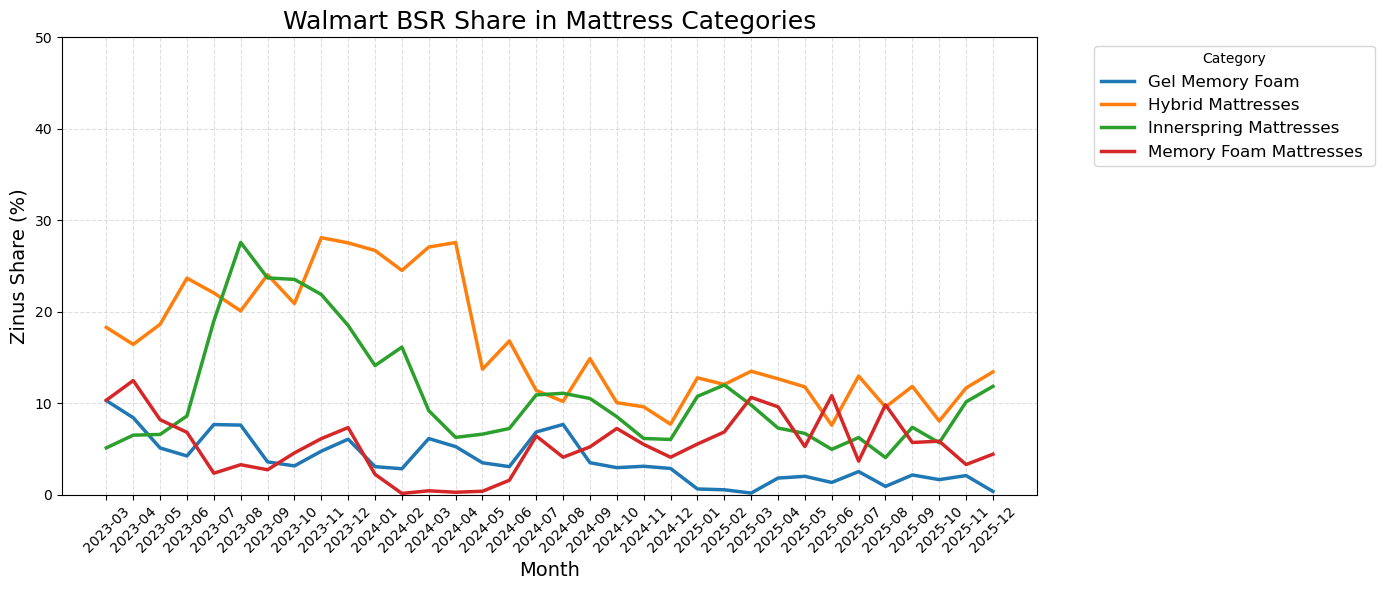

In [111]:
#pivot_no_mattress = pivot_share.drop(index='Mattress', errors='ignore')
#pivot_plot = pivot_no_mattress.copy()

pivot_plot = pivot_share.copy()
pivot_plot = pivot_plot.reindex(sorted(pivot_plot.columns), axis=1)

# Mattress 카테고리가 있다면, 먼저 나오도록 index 재배열
#new_index_order = ['Mattress'] + [cat for cat in pivot_plot.index if cat != 'Mattress']
#pivot_plot = pivot_plot.loc[new_index_order]

# Mattress인 경우, Headboard 제외하기
if "Mattress" in pivot_plot.index:
    pivot_plot = pivot_plot.drop("Mattress")
    
# Non-mattress인 경우, Headboard 제외하기
if "Headboard" in pivot_plot.index:
    pivot_plot = pivot_plot.drop("Headboard")

plt.figure(figsize=(14, 6))

for category in pivot_plot.index:
    plt.plot(pivot_plot.columns,                       # x-axis (월)
             pivot_plot.loc[category],                # y-axis (점유율)
            # marker='o',
             linewidth=2.5,
             label=category)

plt.title("Walmart BSR Share in Mattress Categories", fontsize=18)
#plt.title("Walmart BSR Share in Non-Mattress Categories", fontsize=18)
plt.xlabel("Month", fontsize=14)
plt.ylabel("Zinus Share (%)", fontsize=14)

plt.ylim(0, 50)   # ← ★ Y축 고정 (0~50%)

plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()

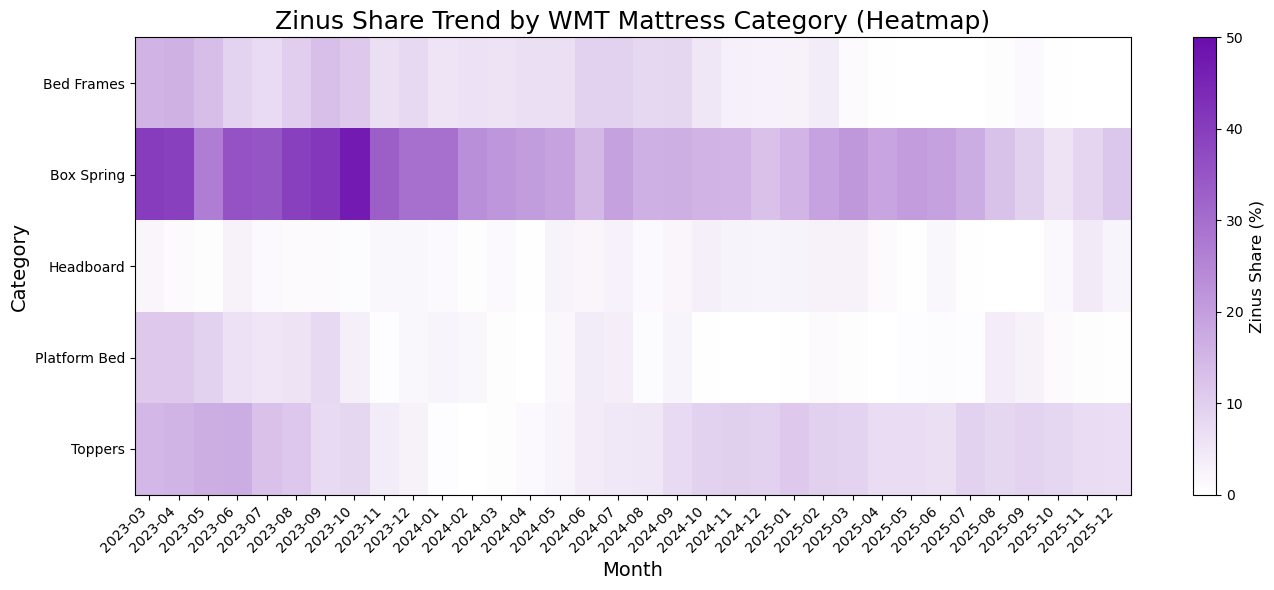

In [97]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

pivot_plot = pivot_share.copy()
pivot_plot = pivot_plot.reindex(sorted(pivot_plot.columns), axis=1)


# ★ 커스텀 색상맵: 최소(흰색) → 최대(보라색)
custom_cmap = LinearSegmentedColormap.from_list(
    "white_to_purple",
    ["#ffffff", "#6a0dad"]   # white → purple
)

plt.figure(figsize=(14, 6))

# 히트맵 그리기
im = plt.imshow(
    pivot_plot.values,
    cmap=custom_cmap,    # ★ 색상 적용
    vmin=0,              # ★ 최소값 고정
    vmax=50,             # ★ 최대값 고정 (50%)
    aspect='auto'
)

# 컬러바(값 범위 표시)
cbar = plt.colorbar(im)
cbar.set_label("Zinus Share (%)", fontsize=12)

# 축 라벨 및 눈금 설정
plt.title("Zinus Share Trend by WMT Mattress Category (Heatmap)", fontsize=18)
plt.xlabel("Month", fontsize=14)
plt.ylabel("Category", fontsize=14)

plt.xticks(
    np.arange(len(pivot_plot.columns)),
    pivot_plot.columns,
    rotation=45,
    ha='right'
)
plt.yticks(
    np.arange(len(pivot_plot.index)),
    pivot_plot.index
)

plt.tight_layout()
plt.show()

## 2. Top Brand BSR Share

#### + Monthly BSR Share

In [33]:

def plot_monthly_brand_share_for_all_categories(
    df,
    category_col='category',
    date_col='bsr_date',      # 날짜 컬럼 (bsr_date / bsr_date_time 등)
    brand_col='brand',
    is_zinus_col='is_zinus_prod',
    unify_zinus=True,
    top_n=10,
    top_base_year=2025        # Top N 브랜드 선정 기준 연도 (예: 2025년 데이터 기준)
):
    """
    df 내의 모든 category에 대해
    - 월별 Top N 브랜드 + Others 로 브랜드 점유율 계산
    - 누적 막대그래프 표시
    """

    # === 0. 날짜 컬럼 datetime 변환 & year_month 생성 (한 번만) ===
    if date_col not in df.columns:
        raise ValueError(f"{date_col} 컬럼이 없습니다.")

    if not pd.api.types.is_datetime64_any_dtype(df[date_col]):
        df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

    df['year_month'] = df[date_col].dt.to_period('M').astype(str)

    # 카테고리 리스트 추출
    categories = (
        df[category_col]
        .dropna()
        .unique()
        .tolist()
    )

    for cat in sorted(categories):
        # 1. 카테고리별 필터링
        df_use = df[df[category_col] == cat].copy()
        if df_use.empty:
            print(f"[SKIP] category='{cat}' : 데이터 없음")
            continue

        # (선택) 지누스 통합 표시
        if unify_zinus and is_zinus_col in df_use.columns:
            df_use.loc[df_use[is_zinus_col] == 'Y', brand_col] = 'Zinus'

        # === 2. 월별, 브랜드별 row 개수 ===
        monthly_brand_counts = (
            df_use.groupby(['year_month', brand_col])
                  .size()
                  .reset_index(name='brand_count')
        )

        # === 3. 월별 전체 row 개수 ===
        monthly_total = (
            df_use.groupby('year_month')
                  .size()
                  .reset_index(name='total_count')
        )

        # === 4. merge 해서 점유율 계산 ===
        monthly_brand_counts = monthly_brand_counts.merge(
            monthly_total, on='year_month'
        )
        monthly_brand_counts['share'] = (
            monthly_brand_counts['brand_count'] /
            monthly_brand_counts['total_count']
        )

        # === 5. 특정 연도(예: 2025년) 데이터만으로 Top N 브랜드 선정 ===
        if top_base_year is not None:
            start_ts = pd.Timestamp(f'{top_base_year}-01-01')
            df_topyear = df_use[df_use[date_col] >= start_ts].copy()
        else:
            df_topyear = df_use.copy()

        if not df_topyear.empty:
            top_brands = (
                df_topyear.groupby(brand_col)
                          .size()
                          .sort_values(ascending=False)
                          .head(top_n)
                          .index
            )
        else:
            # 해당 연도 데이터 없으면 전체 기간 기준으로 선정
            top_brands = (
                monthly_brand_counts.groupby(brand_col)['brand_count']
                                    .sum()
                                    .sort_values(ascending=False)
                                    .head(top_n)
                                    .index
            )

        # === 6. Top N 이외는 Others로 변환 ===
        monthly_brand_counts['brand_adj'] = monthly_brand_counts[brand_col].where(
            monthly_brand_counts[brand_col].isin(top_brands),
            'Others'
        )

        # === 7. 월별 다시 집계 (Others 포함) ===
        monthly_top = (
            monthly_brand_counts.groupby(['year_month', 'brand_adj'])
                               .agg({'brand_count': 'sum',
                                     'total_count': 'first'})
                               .reset_index()
        )
        monthly_top['share'] = (
            monthly_top['brand_count'] /
            monthly_top['total_count']
        )

        # === 8. 피벗 테이블 (index = year_month, columns = 브랜드, value = share) ===
        pivot_df = (
            monthly_top.pivot(index='year_month',
                              columns='brand_adj',
                              values='share')
                      .fillna(0)
        )

        # === 9. 전체 비중 기준 컬럼 순서 재정렬 (Zinus 아래, Others 위, 나머지는 비중 내림차순) ===
        brand_total = (
            monthly_top.groupby('brand_adj')
                      .agg(brand_count_sum=('brand_count', 'sum'),
                           total_count_sum=('total_count', 'sum'))
                      .assign(overall_share=lambda d: d['brand_count_sum'] /
                                                      d['total_count_sum'])
                      .reset_index()
        )

        present_cols = set(pivot_df.columns)
        brand_total = brand_total[brand_total['brand_adj'].isin(present_cols)]

        others_present = 'Others' in present_cols
        zinus_present = 'Zinus' in present_cols

        # Others / Zinus 제외한 나머지 브랜드를 overall_share 기준 정렬
        middle_order = (
            brand_total[~brand_total['brand_adj'].isin(['Others', 'Zinus'])]
            .sort_values('overall_share', ascending=False)['brand_adj']
            .tolist()
        )

        ordered_cols = []
        if zinus_present:
            ordered_cols.append('Zinus')          # 스택 맨 아래
        ordered_cols.extend([c for c in middle_order if c not in ordered_cols])
        if others_present:
            ordered_cols.append('Others')         # 스택 맨 위

        pivot_df = pivot_df[ordered_cols]
        
        print(pivot_df)

        # === 10. 색상 지정 (Others 회색, Zinus 파란색, 나머지는 tab20) ===
        default_colors = plt.cm.tab20.colors
        color_map = {}

        for i, col in enumerate(pivot_df.columns):
            if col == 'Others':
                color_map[col] = 'lightgrey'
            elif col == 'Zinus':
                color_map[col] = 'steelblue'
            else:
                color_map[col] = default_colors[i % len(default_colors)]

        colors = [color_map[c] for c in pivot_df.columns]

        # === 11. 월별 TopN(+Others) 브랜드 점유율 누적 막대그래프 ===
        fig, ax = plt.subplots(figsize=(12, 6))

        pivot_df.plot(kind='bar',
                      stacked=True,
                      ax=ax,
                      color=colors)

        title_year = f"(Top {top_n}, Base {top_base_year})" if top_base_year else f"(Top {top_n})"
        ax.set_title(f"{cat} - Monthly Brand Share {title_year}", fontsize=18)
        ax.set_xlabel('Year-Month', fontsize=14)
        ax.set_ylabel('Share', fontsize=14)

        # x축 라벨 회전
        ax.set_xticklabels(pivot_df.index, rotation=45, ha='right')

        ax.legend(title='Brand', bbox_to_anchor=(1.05, 1),
                  loc='upper left', fontsize=14)
        plt.tight_layout()

        # 결과 그래프 저장
        filename = f"brandshare_monthly_{cat}.png"
        plt.savefig(filename, dpi=350, bbox_inches='tight')

        plt.show()

# 사용 예시
# plot_monthly_brand_share_for_all_categories(df)

brand_adj    Vipbear     MLILY  Cool Gel  Classic Brands/Vibe  Serta/Simmons  \
year_month                                                                     
2023-03     0.000000  0.072165  0.000000             0.001718       0.060137   
2023-04     0.000000  0.066239  0.004274             0.006410       0.059829   
2023-05     0.000000  0.082609  0.006522             0.000000       0.056522   
2023-06     0.000000  0.069817  0.008593             0.000000       0.045113   
2023-07     0.000000  0.076367  0.014448             0.001032       0.023736   
2023-08     0.000000  0.113043  0.028261             0.000000       0.032609   
2023-09     0.000000  0.135706  0.035595             0.000000       0.016685   
2023-10     0.000000  0.105664  0.043573             0.000000       0.025054   
2023-11     0.000000  0.095238  0.058693             0.000000       0.037652   
2023-12     0.000000  0.123106  0.068182             0.000000       0.028409   
2024-01     0.000000  0.107676  0.054371

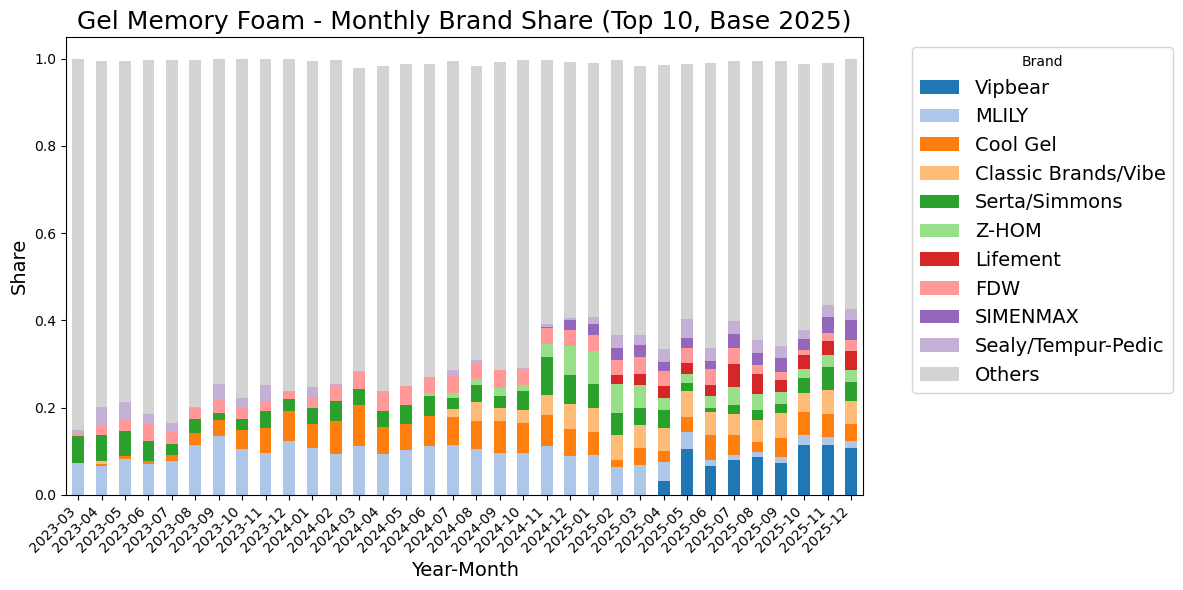

brand_adj      Zinus    Nisien    Avenco  Babo Care     GREOO  Famistar  \
year_month                                                                
2023-03     0.208633  0.000000  0.023381   0.000000  0.000000  0.005396   
2023-04     0.190217  0.000000  0.056522   0.000000  0.000000  0.026087   
2023-05     0.195975  0.000000  0.043432   0.000000  0.000000  0.026483   
2023-06     0.220463  0.000000  0.010962   0.000000  0.000000  0.035323   
2023-07     0.208609  0.000000  0.041943   0.000000  0.000000  0.029801   
2023-08     0.204522  0.045221  0.047276   0.000000  0.000000  0.048304   
2023-09     0.258675  0.039958  0.041009   0.000000  0.000000  0.060988   
2023-10     0.231088  0.081865  0.036269   0.000000  0.000000  0.074611   
2023-11     0.278013  0.053911  0.024313   0.000000  0.000000  0.022199   
2023-12     0.285441  0.065134  0.022989   0.000000  0.000000  0.026820   
2024-01     0.268712  0.092025  0.042945   0.000000  0.000000  0.017178   
2024-02     0.236667  0.0

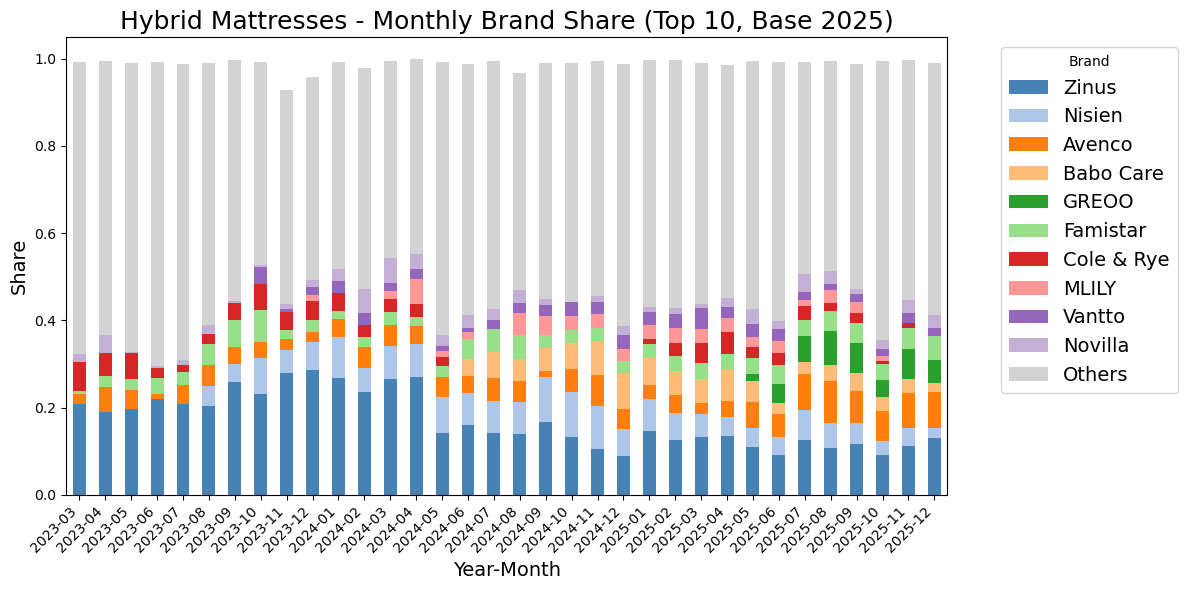

brand_adj      Zinus   Crystli  Serta/Simmons  Mellow/BPM  \
year_month                                                  
2023-03     0.070588  0.063866       0.000000    0.060504   
2023-04     0.074612  0.086240       0.000000    0.056202   
2023-05     0.062564  0.069744       0.000000    0.056410   
2023-06     0.080423  0.039153       0.000000    0.059259   
2023-07     0.173173  0.035035       0.000000    0.034034   
2023-08     0.255193  0.061325       0.000000    0.049456   
2023-09     0.223911  0.061803       0.000000    0.078014   
2023-10     0.232246  0.042226       0.023992    0.080614   
2023-11     0.211009  0.023445       0.019368    0.080530   
2023-12     0.180000  0.030909       0.016364    0.069091   
2024-01     0.132673  0.071287       0.010891    0.076238   
2024-02     0.151042  0.040625       0.027083    0.081250   
2024-03     0.097130  0.069536       0.077263    0.068433   
2024-04     0.072797  0.088123       0.094828    0.075670   
2024-05     0.071499  0.

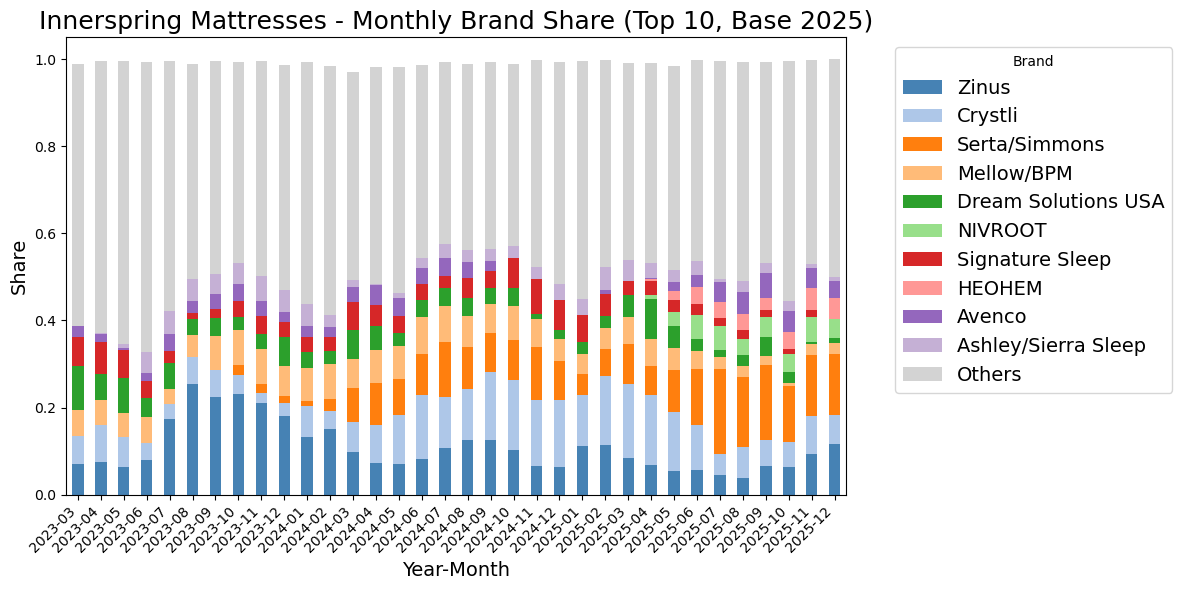

brand_adj      Zinus  Mainstays     MLILY    Kizreo   CICIMLU    Nisien  \
year_month                                                                
2023-03     0.138462   0.265934  0.017582  0.000000  0.000000  0.000000   
2023-04     0.130137   0.250685  0.023288  0.000000  0.000000  0.000000   
2023-05     0.118421   0.182566  0.027961  0.000000  0.000000  0.000000   
2023-06     0.110132   0.151248  0.023495  0.000000  0.000000  0.000000   
2023-07     0.107969   0.102828  0.034704  0.000000  0.000000  0.000000   
2023-08     0.180837   0.116059  0.025641  0.000000  0.000000  0.004049   
2023-09     0.153740   0.156510  0.022161  0.000000  0.000000  0.004155   
2023-10     0.148718   0.100000  0.025641  0.000000  0.000000  0.019231   
2023-11     0.019544   0.011944  0.002172  0.000000  0.000000  0.020630   
2023-12     0.031558   0.019724  0.013807  0.000000  0.000000  0.017751   
2024-01     0.015773   0.003155  0.004206  0.000000  0.000000  0.004206   
2024-02     0.030879   0.

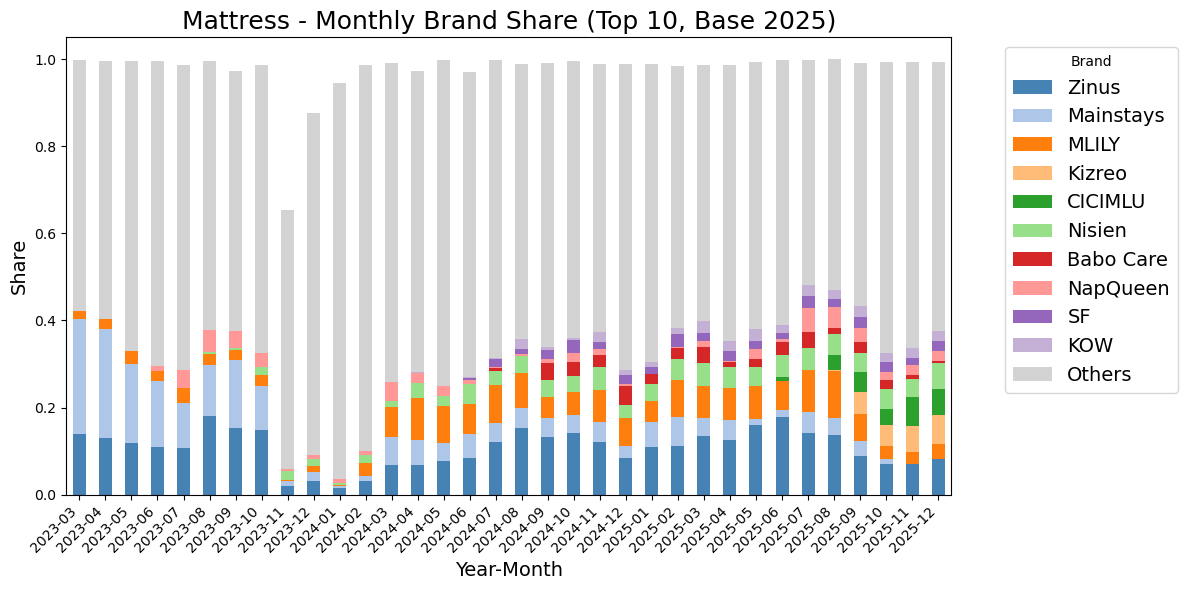

brand_adj      Zinus     MLILY  Lecuneey     FCCTO    GELBIY  SynthoSpace  \
year_month                                                                  
2023-03     0.115865  0.028520  0.000000  0.000000  0.000000     0.000000   
2023-04     0.125263  0.053684  0.000000  0.000000  0.000000     0.000000   
2023-05     0.105085  0.042938  0.000000  0.000000  0.000000     0.000000   
2023-06     0.095293  0.086108  0.000000  0.000000  0.000000     0.000000   
2023-07     0.044917  0.067376  0.000000  0.000000  0.000000     0.000000   
2023-08     0.053593  0.124239  0.000000  0.000000  0.000000     0.000000   
2023-09     0.034524  0.067857  0.000000  0.000000  0.000000     0.000000   
2023-10     0.051860  0.075536  0.000000  0.000000  0.000000     0.000000   
2023-11     0.072748  0.120092  0.000000  0.000000  0.000000     0.000000   
2023-12     0.077519  0.067829  0.000000  0.000000  0.000000     0.000000   
2024-01     0.022779  0.063781  0.000000  0.000000  0.000000     0.000000   

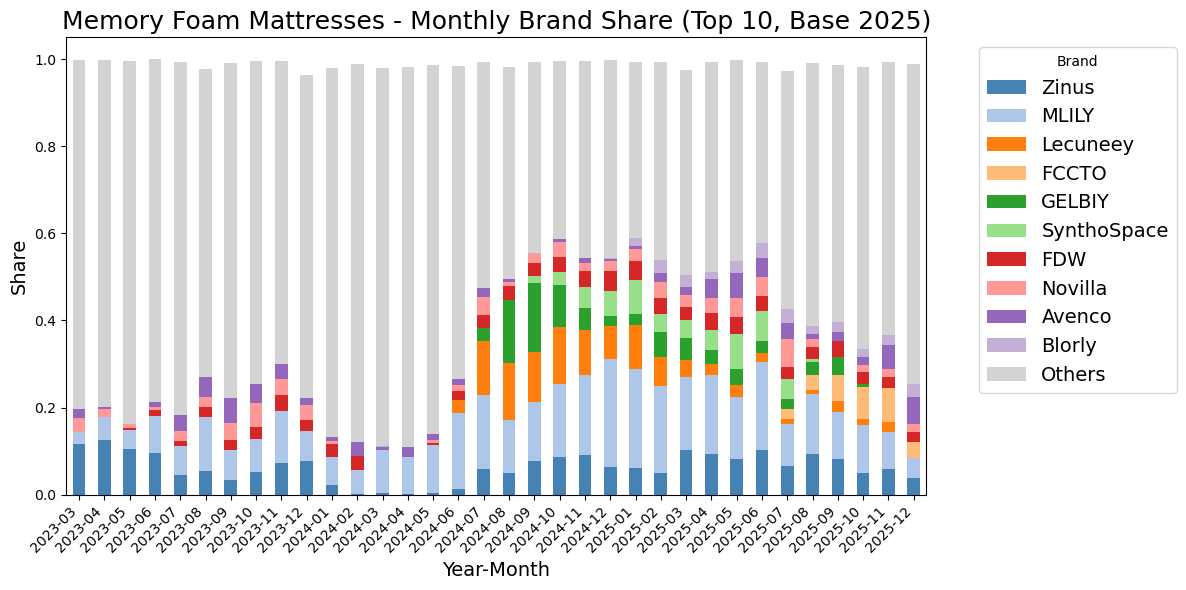

In [35]:
# 1️⃣ 분류 기준 리스트
mattress_list = [
    'Mattress',
    'Innerspring Mattresses',
    'Memory Foam Mattresses',
    'Gel Memory Foam',
    'Hybrid Mattresses'
]

# 2️⃣ category가 위 리스트에 해당하는 것만 필터링
df_mattress = df[df['category'].isin(mattress_list)].copy()

#print(df_mattress['category'].value_counts())  # 체크용

# 3️⃣ 월별 Top10 브랜드 점유율 그래프 (매트리스 카테고리만)
plot_monthly_brand_share_for_all_categories(
    df_mattress,
    category_col='category',
    date_col='bsr_date',        # bsr_date_col 이름에 맞게 수정
    brand_col='brand',
    is_zinus_col='is_zinus_prod',
    unify_zinus=True,
    top_n=10,
    top_base_year=2025
)

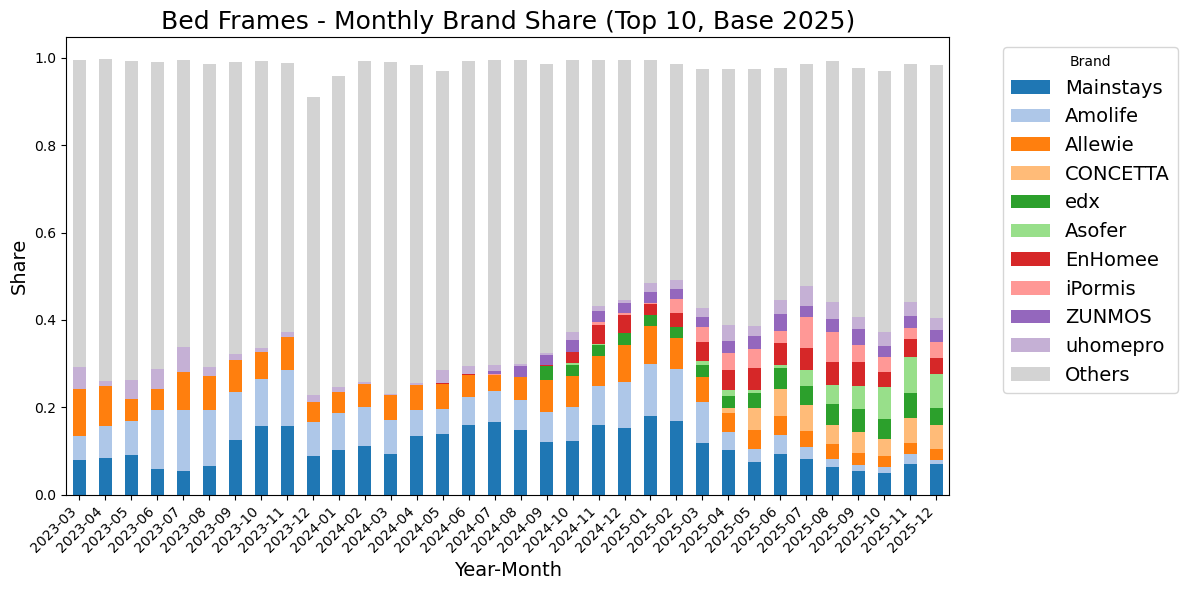

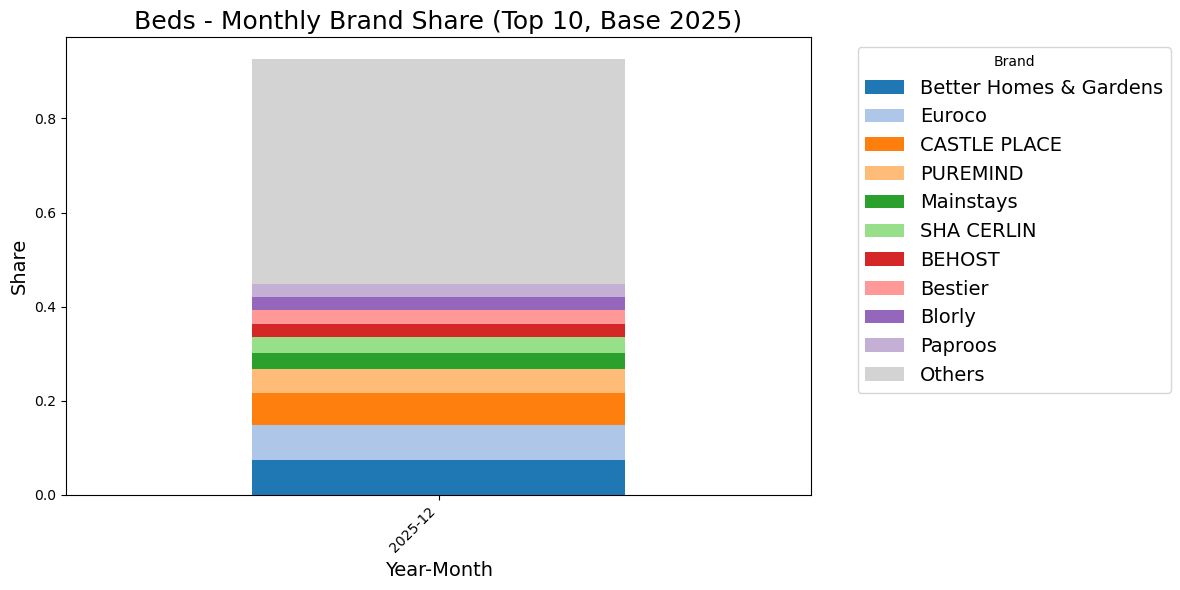

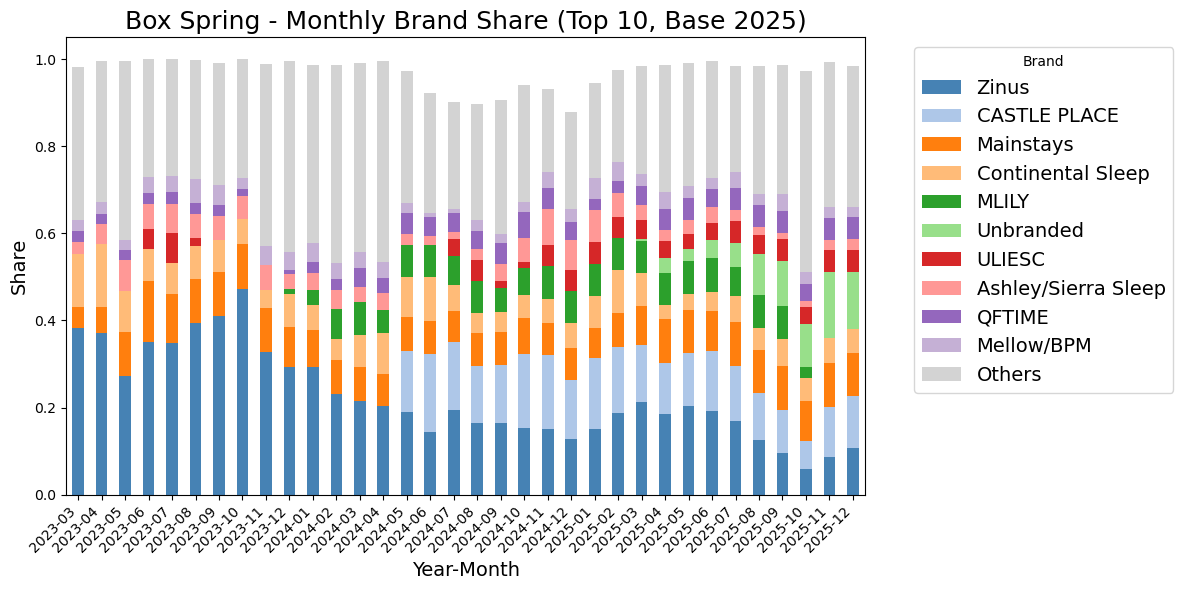

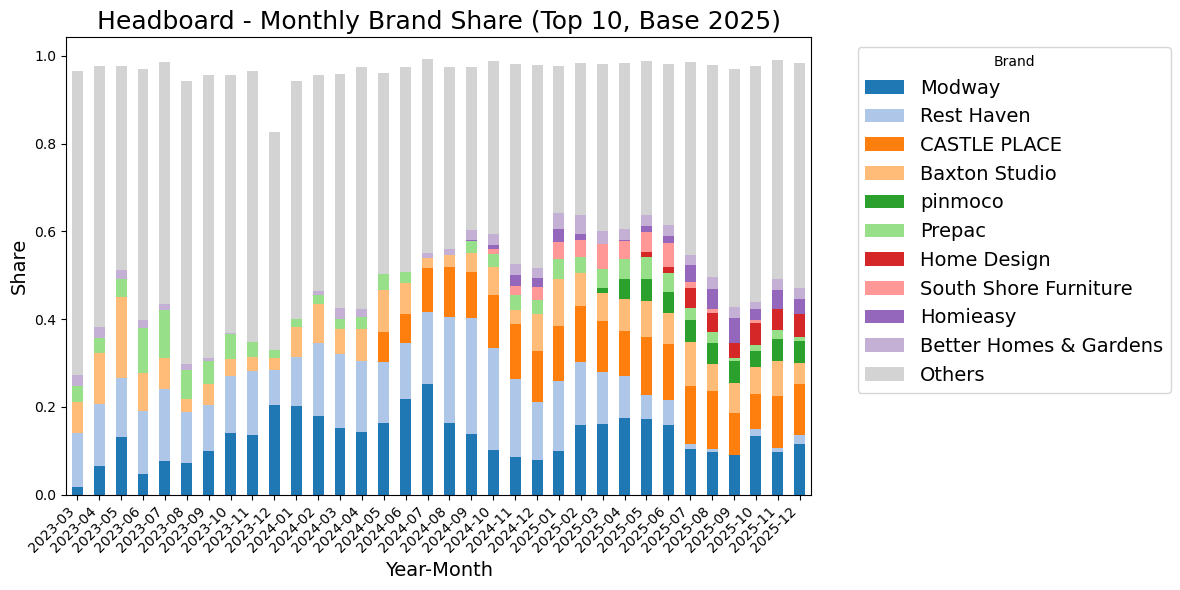

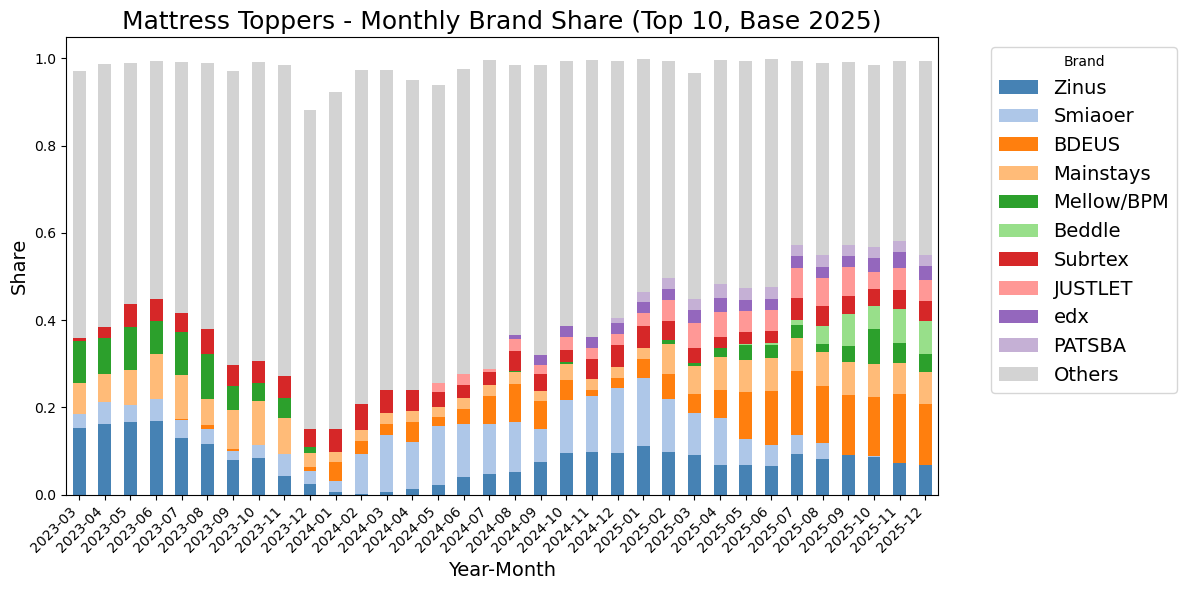

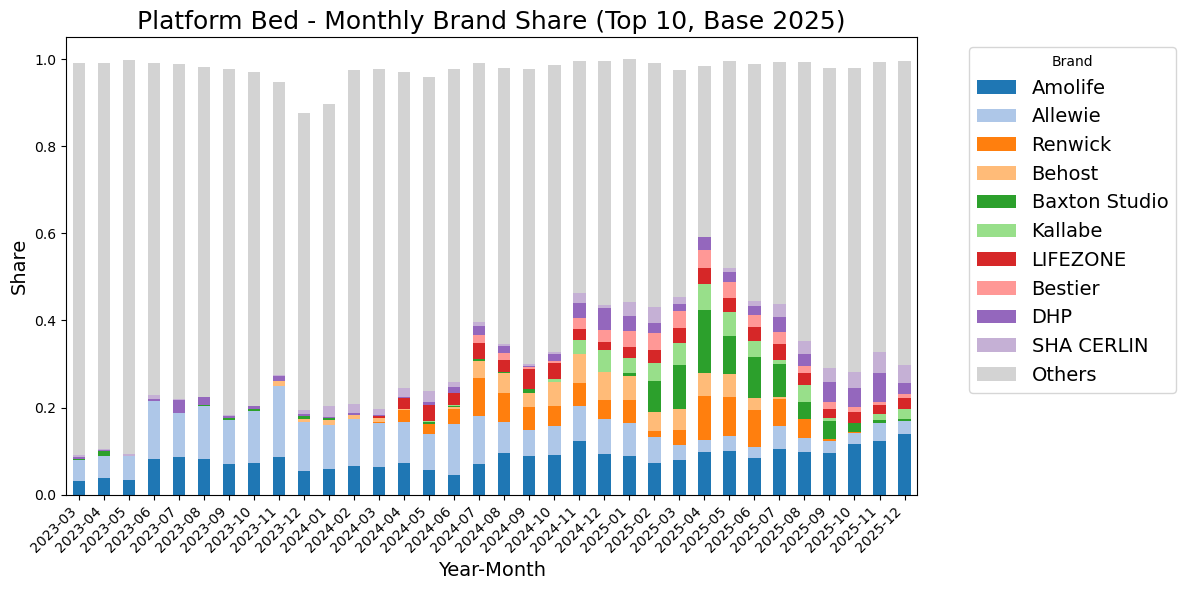

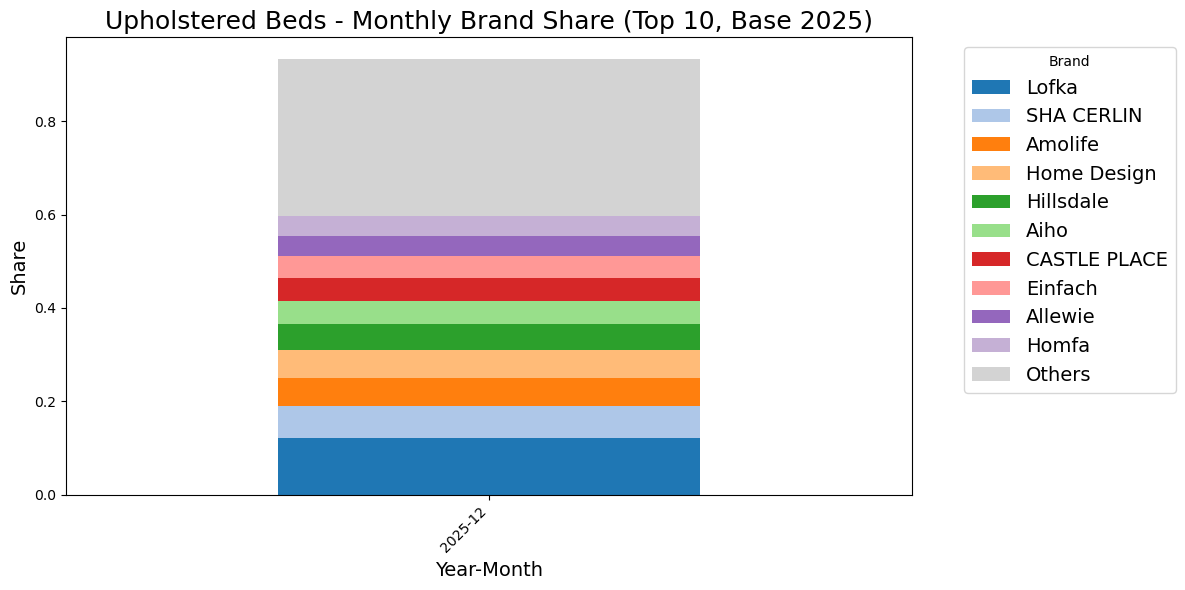

In [25]:

df_non_matt = df1[df1['cate_type']=='non-matt'].copy()

#print(df_mattress['category'].value_counts())  # 체크용

# 3️⃣ 월별 Top10 브랜드 점유율 그래프 (매트리스 카테고리만)
plot_monthly_brand_share_for_all_categories(
    df_non_matt,
    category_col='category',
    date_col='bsr_date',        # bsr_date_col 이름에 맞게 수정
    brand_col='brand',
    is_zinus_col='is_zinus_prod',
    unify_zinus=True,
    top_n=10,
    top_base_year=2025
)

#### + Yearly BSR Share

In [27]:
df2 = df.copy()
df2['bsr_date'] = pd.to_datetime(df2['bsr_date'], errors='coerce')
df2['year'] = df2['bsr_date'].dt.year

In [28]:
df2.columns.tolist()

['category',
 'is_zinus_prod',
 'product_item_id',
 'product_url',
 'product_name',
 'brand',
 'brand_raw',
 'seller_type',
 'seller_name',
 'rating',
 'bsr_date_time',
 'bsr_date',
 'yr_week',
 'rank',
 'curpage',
 'position_overall',
 'list_price',
 'retail_price',
 'price_discount_percentage',
 'has_stock',
 'brand_oth',
 'brand_legend_num',
 'brand_legend_ord',
 'page_label',
 'year']

In [39]:
top_n = 10
base_year = 2025   # ✅ 2025년 기준으로 Top10 선정

cate_list = df2['category'].dropna().unique()

# 3️⃣ 카테고리별 연도별 점유율 테이블
for cat in sorted(cate_list):
    if cat != 'Gel Memory Foam': 
        continue
    
    df_cat = df2[df2['category'] == cat].copy()
    if df_cat.empty:
        print(f"[SKIP] category='{cat}' : 데이터 없음")
        continue

    # Zinus 통합 (옵션)
    if 'is_zinus_prod' in df_cat.columns:
        df_cat.loc[df_cat['is_zinus_prod'] == 'Y', 'brand'] = 'Zinus'

    # --- ① 연도-브랜드별 count / 전체 count / 1차 share 계산 ---
    yearly_brand_counts = (
        df_cat.groupby(['year', 'brand'])
              .size()
              .reset_index(name='brand_count')
    )
    
    yearly_total = (
        df_cat.groupby('year')
              .size()
              .reset_index(name='total_count')
    )
    print(yearly_total)
    
    yearly_brand_counts = yearly_brand_counts.merge(yearly_total, on='year', how='left')
    yearly_brand_counts['share'] = (
        yearly_brand_counts['brand_count'] / yearly_brand_counts['total_count']
    )

    print(yearly_brand_counts)

    # --- ② 2025년 기준 Top10 브랜드 선정 ---
    df_base = yearly_brand_counts[yearly_brand_counts['year'] == base_year].copy()
    if df_base.empty:
        # 2025년 데이터가 없으면 전체 기간 기준으로 Top10
        top_brands = (
            yearly_brand_counts.groupby('brand')['brand_count']
                               .sum()
                               .sort_values(ascending=False)
                               .head(top_n)
                               .index
        )
        print(f"[WARN] category='{cat}' : {base_year} 데이터 없음 → 전체 기준 Top{top_n}")
    else:
        top_brands = (
            df_base.groupby('brand')['brand_count']
                   .sum()
                   .sort_values(ascending=False)
                   .head(top_n)
                   .index
        )

    # --- ③ Top10 이 아닌 브랜드는 'Others' 로 묶기 ---
    yearly_brand_counts['brand_adj'] = np.where(
        yearly_brand_counts['brand'].isin(top_brands),
        yearly_brand_counts['brand'],
        'Others'
    )

    # --- ④ 연도-브랜드_adj 기준으로 집계 후 최종 share 계산 ---
    yearly_top = (
        yearly_brand_counts.groupby(['year', 'brand_adj'])['brand_count']
                           .sum()
                           .reset_index()
    )

    yearly_total2 = (
        yearly_top.groupby('year')['brand_count']
                  .sum()
                  .reset_index(name='total_count')
    )

    yearly_top = yearly_top.merge(yearly_total2, on='year', how='left')
    yearly_top['share'] = yearly_top['brand_count'] / yearly_top['total_count']

    # --- ⑤ 전체 비중 기준으로 브랜드 순서 정렬 (Zinus 위, Others 아래) ---
    brand_total = (
        yearly_top.groupby('brand_adj')['brand_count']
                  .sum()
                  .reset_index(name='brand_count_sum')
    )
    brand_total['overall_share'] = (
        brand_total['brand_count_sum'] / brand_total['brand_count_sum'].sum()
    )

    brands_present = brand_total['brand_adj'].tolist()

    middle_order = (
        brand_total[~brand_total['brand_adj'].isin(['Zinus', 'Others'])]
        .sort_values('overall_share', ascending=False)['brand_adj']
        .tolist()
    )

    ordered_idx = []
    if 'Zinus' in brands_present:
        ordered_idx.append('Zinus')
    ordered_idx.extend([b for b in middle_order if b not in ordered_idx])
    if 'Others' in brands_present:
        ordered_idx.append('Others')

    # --- ⑥ 피벗: row = brand_adj, col = year, value = share ---
    pivot_df = (
        yearly_top.pivot(index='brand_adj', columns='year', values='share')
                  .fillna(0)
    )

    # 순서 적용
    pivot_df = pivot_df.loc[ordered_idx]

    # --- ⑦ 결과 출력 ---
    print("=" * 80)
    print(f"[{cat}] Yearly Brand Share (Top{top_n} by {base_year}, Others 포함)")
    print((pivot_df * 100).round(1))   # %로 보기 쉽게

   year  total_count
0  2023         8506
1  2024        11560
2  2025        11809
     year                brand  brand_count  total_count     share
0    2023           AC Pacific           35         8506  0.004115
1    2023       ARCTICSCORPION            2         8506  0.000235
2    2023  Ashley/Sierra Sleep           62         8506  0.007289
3    2023               Avenco           72         8506  0.008465
4    2023           Beautyrest           17         8506  0.001999
..    ...                  ...          ...          ...       ...
280  2025                miree           51        11809  0.004319
281  2025      nue by Novaform           64        11809  0.005420
282  2025              sersper          160        11809  0.013549
283  2025              serweet           10        11809  0.000847
284  2025            unbranded            1        11809  0.000085

[285 rows x 5 columns]
[Gel Memory Foam] Yearly Brand Share (Top10 by 2025, Others 포함)
year                 202

#### -- Weekly BSR Share 

<Figure size 1400x600 with 0 Axes>

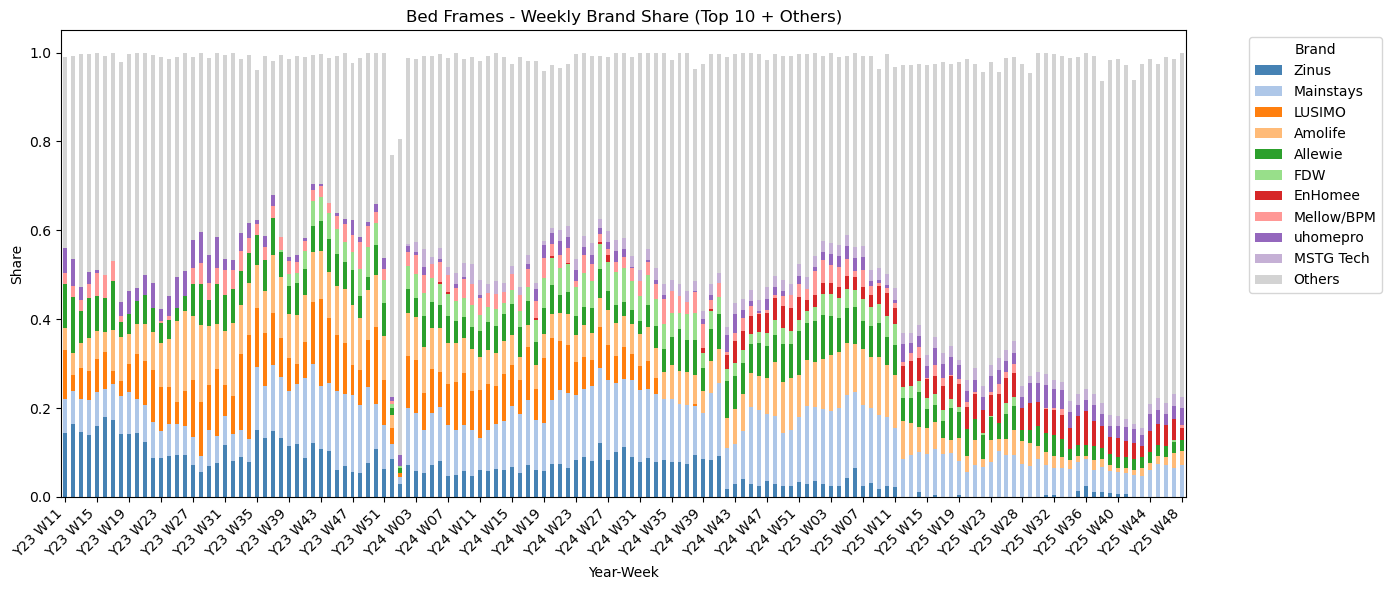

<Figure size 1400x600 with 0 Axes>

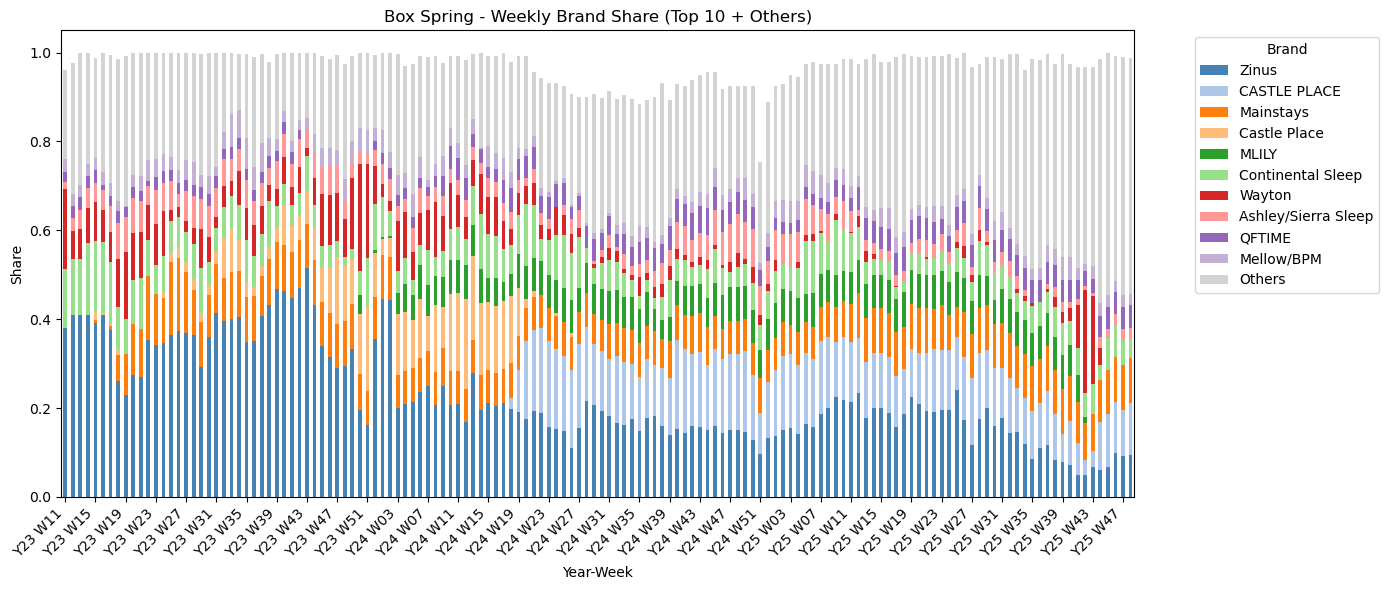

<Figure size 1400x600 with 0 Axes>

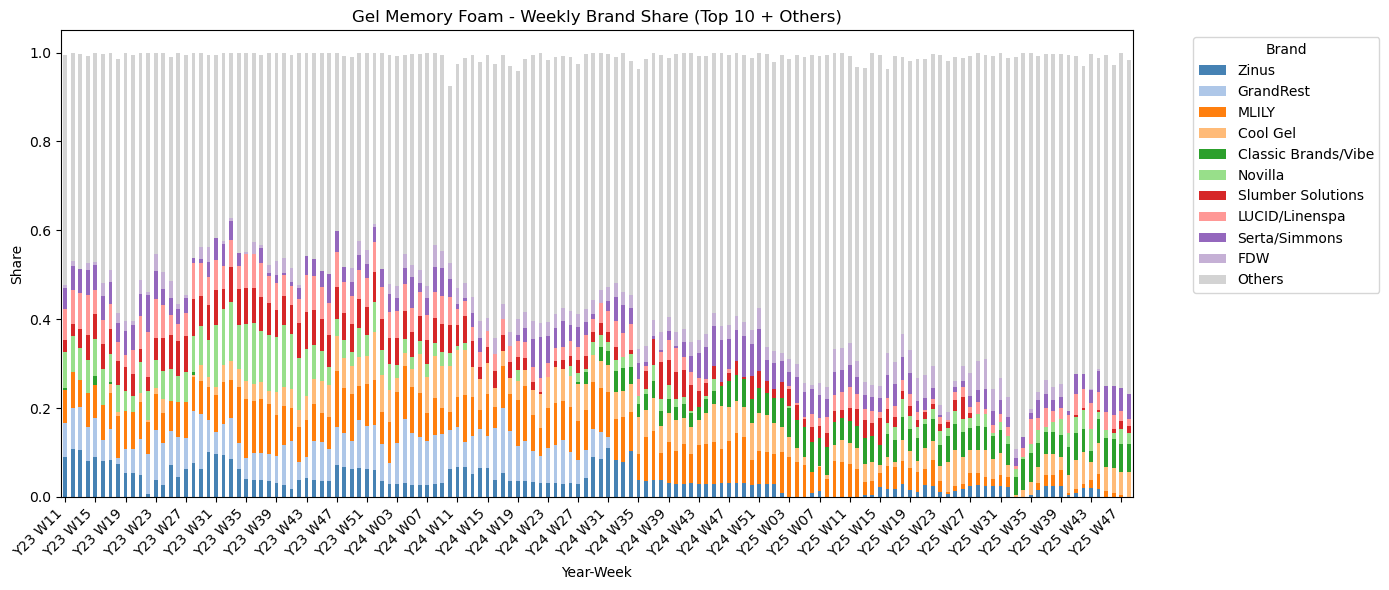

<Figure size 1400x600 with 0 Axes>

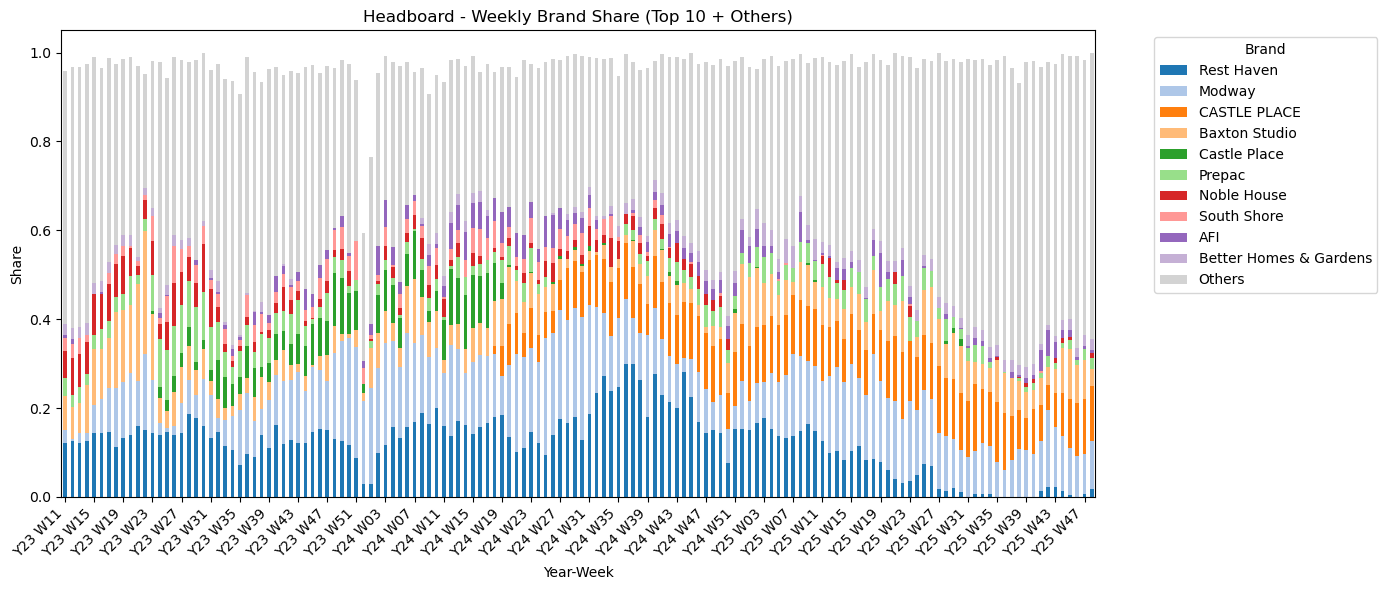

<Figure size 1400x600 with 0 Axes>

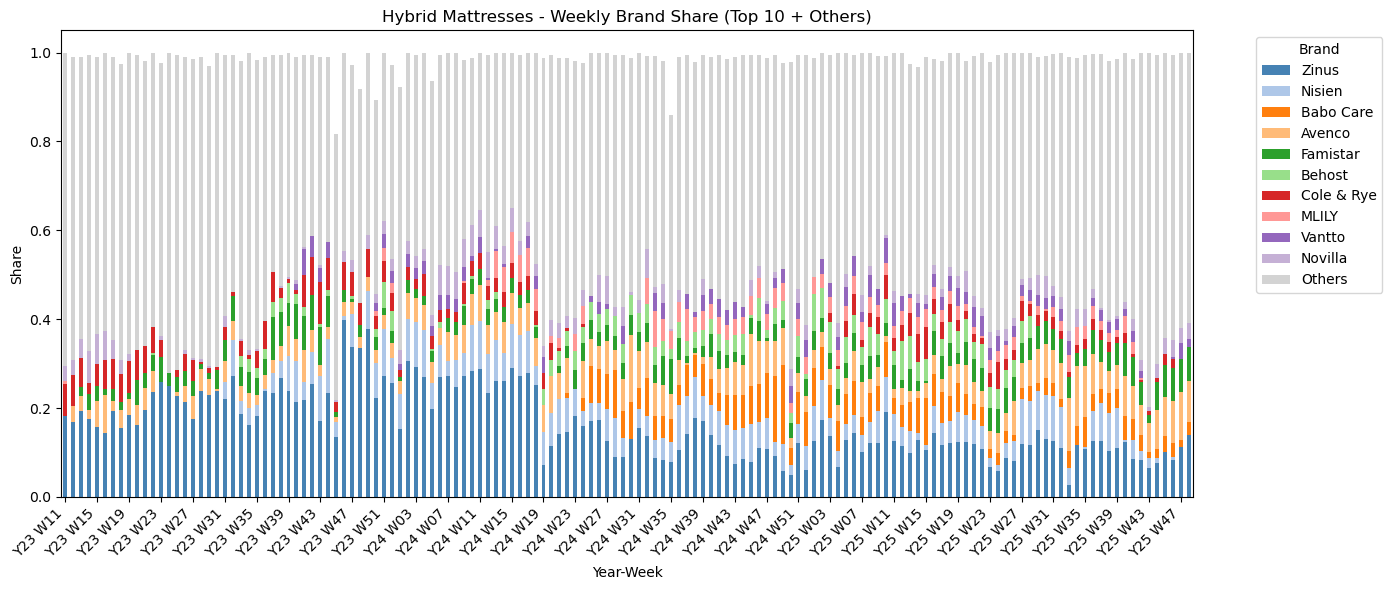

<Figure size 1400x600 with 0 Axes>

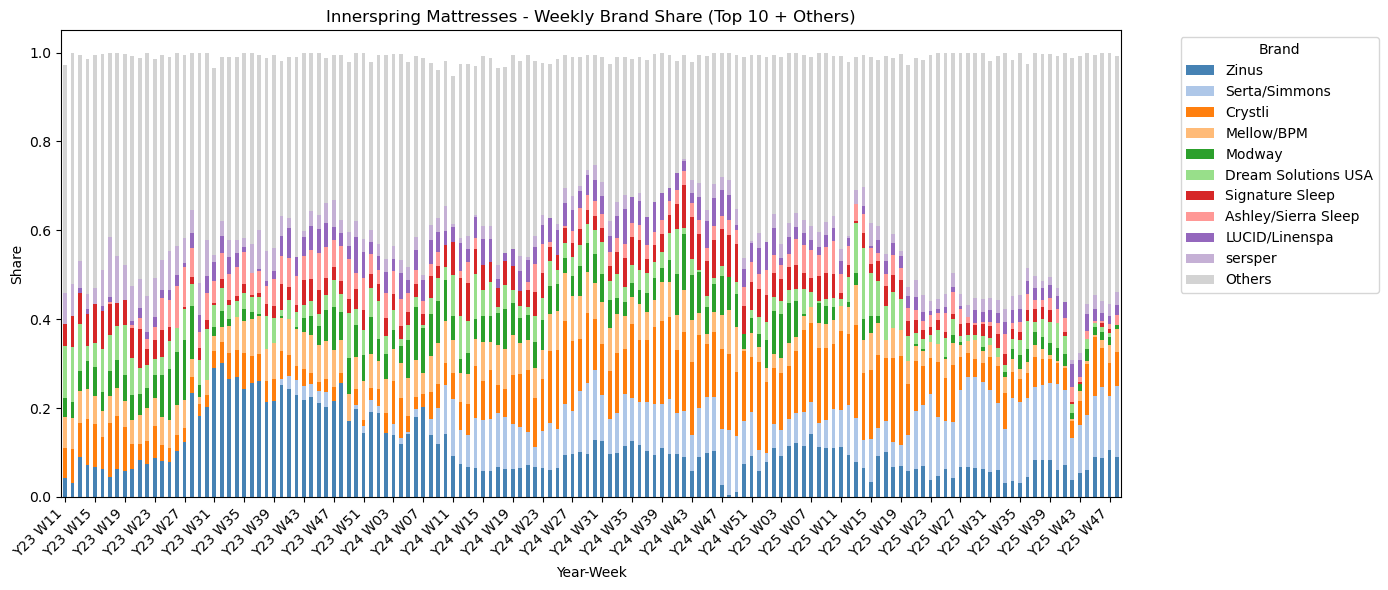

<Figure size 1400x600 with 0 Axes>

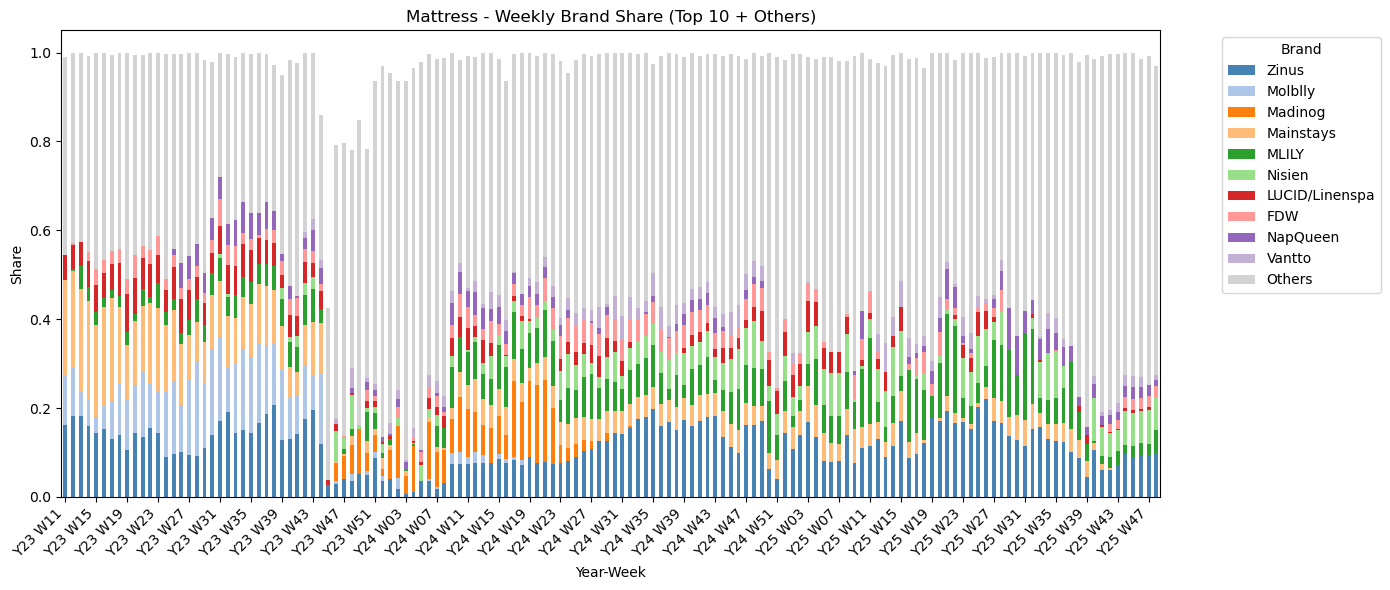

<Figure size 1400x600 with 0 Axes>

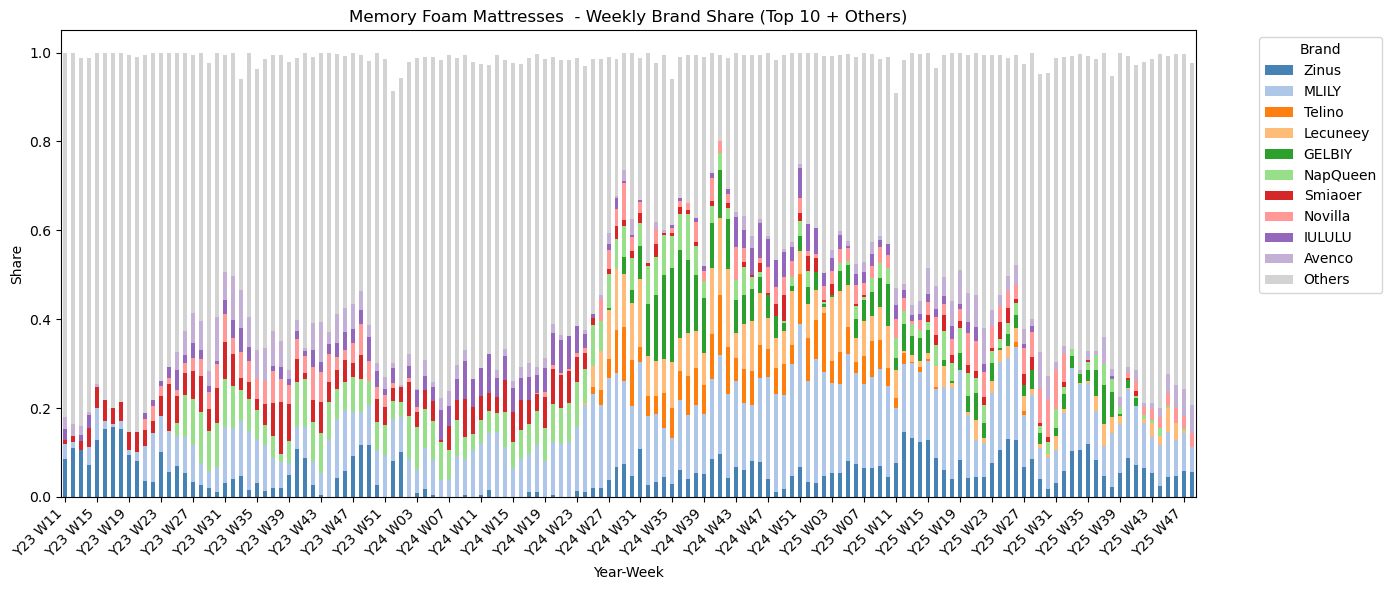

<Figure size 1400x600 with 0 Axes>

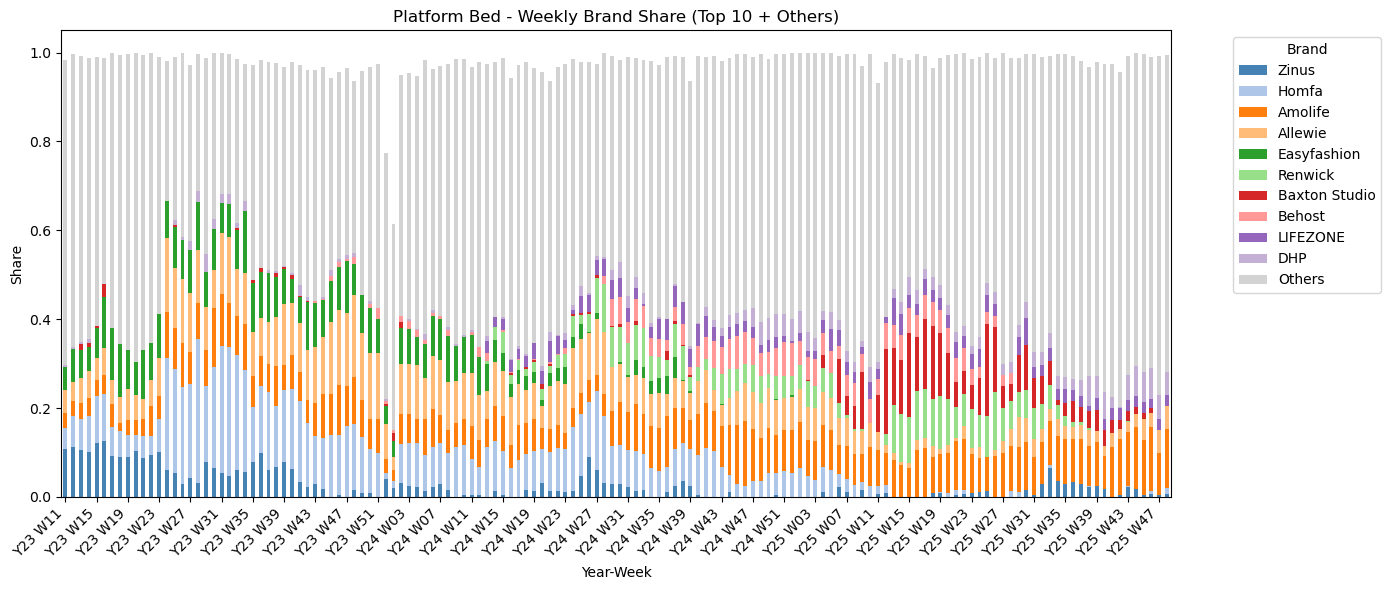

<Figure size 1400x600 with 0 Axes>

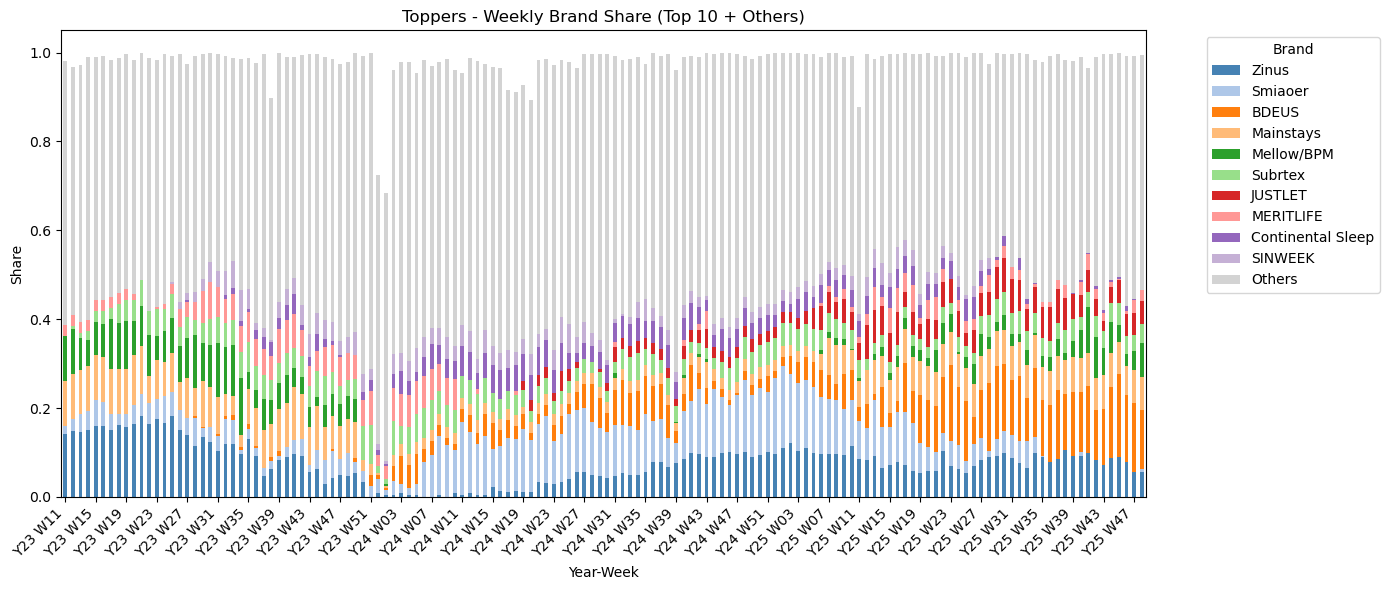

In [13]:

def plot_weekly_brand_share_for_all_categories(
    df,
    category_col='category',
    yr_week_col='yr_week',
    brand_col='brand',
    is_zinus_col='is_zinus_prod',
    unify_zinus=True,
    top_n=10
):
    """
    df 내의 모든 category에 대해
    - 주별 Top N 브랜드 + Others 로 브랜드 점유율 계산
    - 누적 막대그래프 표시
    """

    # 카테고리 리스트 추출
    categories = (
        df[category_col]
        .dropna()
        .unique()
        .tolist()
    )

    for cat in sorted(categories):
        # 0. 카테고리별 필터링
        df_use = df[df[category_col] == cat].copy()
        if df_use.empty:
            print(f"[SKIP] category='{cat}' : 데이터 없음")
            continue

        # (선택) 지누스 통합 표시
        if unify_zinus and is_zinus_col in df_use.columns:
            df_use.loc[df_use[is_zinus_col] == 'Y', brand_col] = 'Zinus'

        # === 1. 주별, 브랜드별 row 개수 ===
        weekly_brand_counts = (
            df_use.groupby([yr_week_col, brand_col])
                  .size()
                  .reset_index(name='brand_count')
        )

        # === 2. 주별 전체 row 개수 ===
        weekly_total = (
            df_use.groupby(yr_week_col)
                  .size()
                  .reset_index(name='total_count')
        )

        # === 3. merge 해서 점유율 계산 ===
        weekly_brand_counts = weekly_brand_counts.merge(
            weekly_total, on=yr_week_col
        )
        weekly_brand_counts['share'] = (
            weekly_brand_counts['brand_count'] /
            weekly_brand_counts['total_count']
        )

        # === 4. 전체 기간 합산 후 Top N 브랜드 선정 ===
        top_brands = (
            weekly_brand_counts.groupby(brand_col)['brand_count']
                               .sum()
                               .sort_values(ascending=False)
                               .head(top_n)
                               .index
        )

        # === 5. Top N 이외는 Others로 변환 ===
        weekly_brand_counts['brand_adj'] = weekly_brand_counts[brand_col].where(
            weekly_brand_counts[brand_col].isin(top_brands),
            'Others'
        )

        # === 6. 주별 다시 집계 (Others 포함) ===
        weekly_top = (
            weekly_brand_counts.groupby([yr_week_col, 'brand_adj'])
                               .agg({'brand_count': 'sum',
                                     'total_count': 'first'})
                               .reset_index()
        )
        weekly_top['share'] = (
            weekly_top['brand_count'] /
            weekly_top['total_count']
        )

        # === 7. 피벗 테이블 (index = 주, columns = 브랜드, value = share) ===
        pivot_df = (
            weekly_top.pivot(index=yr_week_col,
                             columns='brand_adj',
                             values='share')
                      .fillna(0)
        )

        # === 8. 전체 비중 기준 컬럼 순서 재정렬 (Zinus 아래, Others 위, 나머지는 비중 내림차순) ===
        brand_total = (
            weekly_top.groupby('brand_adj')
                      .agg(brand_count_sum=('brand_count', 'sum'),
                           total_count_sum=('total_count', 'sum'))
                      .assign(overall_share=lambda d: d['brand_count_sum'] /
                                                      d['total_count_sum'])
                      .reset_index()
        )

        present_cols = set(pivot_df.columns)
        brand_total = brand_total[brand_total['brand_adj'].isin(present_cols)]

        others_present = 'Others' in present_cols
        zinus_present = 'Zinus' in present_cols

        # Others / Zinus 제외한 나머지 브랜드를 overall_share 기준 정렬
        middle_order = (
            brand_total[~brand_total['brand_adj'].isin(['Others', 'Zinus'])]
            .sort_values('overall_share', ascending=False)['brand_adj']
            .tolist()
        )

        ordered_cols = []
        if zinus_present:
            ordered_cols.append('Zinus')          # 스택 맨 아래
        ordered_cols.extend([c for c in middle_order if c not in ordered_cols])
        if others_present:
            ordered_cols.append('Others')         # 스택 맨 위

        pivot_df = pivot_df[ordered_cols]

        # === 9. 색상 지정 (Others 회색, Zinus 파란색, 나머지는 tab20) ===
        default_colors = plt.cm.tab20.colors
        color_map = {}

        for i, col in enumerate(pivot_df.columns):
            if col == 'Others':
                color_map[col] = 'lightgrey'
            elif col == 'Zinus':
                color_map[col] = 'steelblue'
            else:
                color_map[col] = default_colors[i % len(default_colors)]

        colors = [color_map[c] for c in pivot_df.columns]

        # === 10. 주별 TopN(+Others) 브랜드 점유율 누적 막대그래프 ===
        plt.figure(figsize=(14, 6))
        ax = pivot_df.plot(kind='bar',
                           stacked=True,
                           figsize=(14, 6),
                           color=colors)

        plt.title(f"{cat} - Weekly Brand Share (Top {top_n} + Others)")
        plt.xlabel('Year-Week')
        plt.ylabel('Share')


        # -------------------------------
        # 🔥 x축 라벨 샘플링 표시
        # -------------------------------
        tick_interval = 4   # 4주 간격으로 표시 (원하면 변경 가능)
        
        ticks = list(range(len(pivot_df.index)))
        ax.set_xticks(ticks[::tick_interval])                 # x축 위치의 간격
        ax.set_xticklabels(pivot_df.index[::tick_interval],   # 실제 라벨 값
                           rotation=45, ha='right')

        
        plt.legend(title='Brand', bbox_to_anchor=(1.05, 1),
                   loc='upper left')
        plt.tight_layout()

        # 결과 그래프 저장하기
        filename = f"brandshare_{cat}.png"
        #save_path = os.path.join(save_folder, filename)
        plt.savefig(filename, dpi=350, bbox_inches='tight')
        
        plt.show()


# === 사용 예시 ===
# 전체 df에 대해 category별 그래프 그리기
#df1 = df[df['yr_week'] >= 'Y24 W01']
plot_weekly_brand_share_for_all_categories(df)



#### -- Weekly Brand Share (2025 기준) 

In [17]:
df1.head(5)

,category,is_zinus_prod,product_item_id,product_url,product_name,brand,brand_raw,seller_type,seller_name,rating,...,list_price,retail_price,price_discount_percentage,has_stock,brand_oth,brand_legend_num,brand_legend_ord,page_label,category_clean,cate_type
0,Upholstered Beds,N,1554457746,https://www.walmart.com/ip/Merrick-Lane-Modern...,Merrick Lane Modern Platform Bed with Upholste...,Merrick Lane,Merrick Lane,3P,First Choice Home,4.2,...,331.99,302.59,0.088557,1,Merrick Lane,2,191,p.1 (1~40),Upholstered Beds,non-matt
1,Beds,N,17417324102,https://www.walmart.com/ip/ANPOO-Full-Size-Mur...,"ANPOO Full Size Murphy Bed with 2 LED Lights, ...",Anpoo,Anpoo,3P,ANPOO,4.5,...,719.99,429.99,0.402783,1,Anpoo,3,190,p.1 (1~40),Beds,non-matt
2,Beds,N,7235400791,https://www.walmart.com/ip/SUNCROWN-Folding-Be...,"SUNCROWN Folding Bed with Mattress, 75"" x 31""P...",Suncrown,Suncrown,3P,Suncrown,4.0,...,NaN,179.99,NaN,1,Suncrown,3,190,p.1 (1~40),Beds,non-matt
3,Beds,N,726653765,https://www.walmart.com/ip/MOPHOTO-75-Portable...,MOPHOTO 75'' Portable Folding Bed Camping Cot ...,MOPHOTO,MOPHOTO,3P,MOPHOTO,4.5,...,NaN,62.98,NaN,1,MOPHOTO,4,189,p.1 (1~40),Beds,non-matt
4,Box Spring,N,309897765,https://www.walmart.com/ip/Casper-Sleep-Box-Sp...,Casper Sleep Box Spring Foundation for Twin Ma...,Casper,Casper,3P,"Amazing Bargains USA, LLC",4.7,...,299.00,279.00,0.066890,1,Casper,264,183,p.1 (1~40),Box Spring,non-matt


In [35]:

def plot_weekly_brand_share_for_all_categories(
    df,
    category_col='category',
    yr_week_col='yr_week',
    brand_col='brand',
    is_zinus_col='is_zinus_prod',
    bsr_date_col='bsr_date',   # ✅ bsr_date 컬럼 이름 파라미터로 추가 (원하면 고정해도 됨)
    unify_zinus=True,
    top_n=10
):
    """
    df 내의 모든 category에 대해
    - 주별 Top N 브랜드 + Others 로 브랜드 점유율 계산
    - 누적 막대그래프 표시
    """

    # 카테고리 리스트 추출
    categories = (
        df[category_col]
        .dropna()
        .unique()
        .tolist()
    )

    # bsr_date를 미리 datetime으로 변환 (한 번만)
    if bsr_date_col in df.columns and not pd.api.types.is_datetime64_any_dtype(df[bsr_date_col]):
        df[bsr_date_col] = pd.to_datetime(df[bsr_date_col], errors='coerce')

    for cat in sorted(categories):
        # 0. 카테고리별 필터링
        df_use = df[df[category_col] == cat].copy()
        if df_use.empty:
            print(f"[SKIP] category='{cat}' : 데이터 없음")
            continue

        # (선택) 지누스 통합 표시
        if unify_zinus and is_zinus_col in df_use.columns:
            df_use.loc[df_use[is_zinus_col] == 'Y', brand_col] = 'Zinus'

        # === 1. 주별, 브랜드별 row 개수 ===
        weekly_brand_counts = (
            df_use.groupby([yr_week_col, brand_col])
                  .size()
                  .reset_index(name='brand_count')
        )

        # === 2. 주별 전체 row 개수 ===
        weekly_total = (
            df_use.groupby(yr_week_col)
                  .size()
                  .reset_index(name='total_count')
        )

        # === 3. merge 해서 점유율 계산 ===
        weekly_brand_counts = weekly_brand_counts.merge(
            weekly_total, on=yr_week_col
        )
        weekly_brand_counts['share'] = (
            weekly_brand_counts['brand_count'] /
            weekly_brand_counts['total_count']
        )

        # === 4. 전체 기간이 아니라, 2025년 데이터만으로 Top N 브랜드 선정 ===
        # 2025년 기준: bsr_date >= '2025-01-01'
        if bsr_date_col in df_use.columns:
            df_2025 = df_use[df_use[bsr_date_col] >= pd.Timestamp('2025-01-01')].copy()
        else:
            df_2025 = pd.DataFrame()  # 컬럼 없으면 빈 DF

        if not df_2025.empty:
            # 2025년 데이터 안에서 브랜드별 row 수 합산
            top_brands = (
                df_2025.groupby(brand_col)
                       .size()
                       .sort_values(ascending=False)
                       .head(top_n)
                       .index
            )
        else:
            # 만약 2025년 데이터가 전혀 없으면, 기존 방식(전체 기간 기준)으로 fallback
            top_brands = (
                weekly_brand_counts.groupby(brand_col)['brand_count']
                                   .sum()
                                   .sort_values(ascending=False)
                                   .head(top_n)
                                   .index
            )

        # === 5. Top N 이외는 Others로 변환 ===
        weekly_brand_counts['brand_adj'] = weekly_brand_counts[brand_col].where(
            weekly_brand_counts[brand_col].isin(top_brands),
            'Others'
        )

        # === 6. 주별 다시 집계 (Others 포함) ===
        weekly_top = (
            weekly_brand_counts.groupby([yr_week_col, 'brand_adj'])
                               .agg({'brand_count': 'sum',
                                     'total_count': 'first'})
                               .reset_index()
        )
        weekly_top['share'] = (
            weekly_top['brand_count'] /
            weekly_top['total_count']
        )

        # === 7. 피벗 테이블 (index = 주, columns = 브랜드, value = share) ===
        pivot_df = (
            weekly_top.pivot(index=yr_week_col,
                             columns='brand_adj',
                             values='share')
                      .fillna(0)
        )

        # === 8. 전체 비중 기준 컬럼 순서 재정렬 (Zinus 아래, Others 위, 나머지는 비중 내림차순) ===
        brand_total = (
            weekly_top.groupby('brand_adj')
                      .agg(brand_count_sum=('brand_count', 'sum'),
                           total_count_sum=('total_count', 'sum'))
                      .assign(overall_share=lambda d: d['brand_count_sum'] /
                                                      d['total_count_sum'])
                      .reset_index()
        )

        present_cols = set(pivot_df.columns)
        brand_total = brand_total[brand_total['brand_adj'].isin(present_cols)]

        others_present = 'Others' in present_cols
        zinus_present = 'Zinus' in present_cols

        # Others / Zinus 제외한 나머지 브랜드를 overall_share 기준 정렬
        middle_order = (
            brand_total[~brand_total['brand_adj'].isin(['Others', 'Zinus'])]
            .sort_values('overall_share', ascending=False)['brand_adj']
            .tolist()
        )

        ordered_cols = []
        if zinus_present:
            ordered_cols.append('Zinus')          # 스택 맨 아래
        ordered_cols.extend([c for c in middle_order if c not in ordered_cols])
        if others_present:
            ordered_cols.append('Others')         # 스택 맨 위

        pivot_df = pivot_df[ordered_cols]

        # === 9. 색상 지정 (Others 회색, Zinus 파란색, 나머지는 tab20) ===
        default_colors = plt.cm.tab20.colors
        color_map = {}

        for i, col in enumerate(pivot_df.columns):
            if col == 'Others':
                color_map[col] = 'white'
            elif col == 'Zinus':
                color_map[col] = 'steelblue'
            else:
                color_map[col] = default_colors[i % len(default_colors)]

        colors = [color_map[c] for c in pivot_df.columns]

        # === 10. 주별 TopN(+Others) 브랜드 점유율 누적 막대그래프 ===
        plt.figure(figsize=(14, 6))
        ax = pivot_df.plot(kind='bar',
                           stacked=True,
                           figsize=(14, 6),
                           color=colors)

        plt.title(f"{cat} - Weekly Brand Share (Top10)", fontsize=16)
        plt.xlabel('Year-Week', fontsize=14)
        plt.ylabel('Share', fontsize=14)

        # 🔥 x축 라벨 샘플링 표시 (4주 간격)
        tick_interval = 4
        ticks = list(range(len(pivot_df.index)))
        ax.set_xticks(ticks[::tick_interval])
        ax.set_xticklabels(pivot_df.index[::tick_interval],
                           rotation=45, ha='right')


        # === 🔥 legend에서 Others 제거 ===
        handles, labels = ax.get_legend_handles_labels()
        filtered = [(h, l) for h, l in zip(handles, labels) if l != 'Others']
        
        ax.legend(
            [h for h, l in filtered],
            [l for h, l in filtered],
            title='Brand',
            bbox_to_anchor=(1.05, 1),
            loc='upper left',
            fontsize=12
        )
#        plt.legend(title='Brand', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
        plt.tight_layout()

                # 결과 그래프 저장하기
        #filename = f"brandshare_2025{cat}.png"
        #plt.savefig(filename, dpi=350, bbox_inches='tight')
        
        plt.show()

#plot_weekly_brand_share_for_all_categories(df)

In [46]:
def plot_weekly_brand_share_for_all_categories2(
    df,
    category_col='category',
    yr_week_col='yr_week',
    brand_col='brand',
    is_zinus_col='is_zinus_prod',
    bsr_date_col='bsr_date',
    unify_zinus=True,
    top_n=10
):

    categories = (
        df[category_col]
        .dropna()
        .unique()
        .tolist()
    )

    if bsr_date_col in df.columns and not pd.api.types.is_datetime64_any_dtype(df[bsr_date_col]):
        df[bsr_date_col] = pd.to_datetime(df[bsr_date_col], errors='coerce')

    for cat in sorted(categories):
        df_use = df[df[category_col] == cat].copy()
        if df_use.empty:
            print(f"[SKIP] category='{cat}' : 데이터 없음")
            continue

        if unify_zinus and is_zinus_col in df_use.columns:
            df_use.loc[df_use[is_zinus_col] == 'Y', brand_col] = 'Zinus'

        weekly_brand_counts = (
            df_use.groupby([yr_week_col, brand_col])
                  .size()
                  .reset_index(name='brand_count')
        )

        weekly_total = (
            df_use.groupby(yr_week_col)
                  .size()
                  .reset_index(name='total_count')
        )

        weekly_brand_counts = weekly_brand_counts.merge(weekly_total, on=yr_week_col)
        weekly_brand_counts['share'] = weekly_brand_counts['brand_count'] / weekly_brand_counts['total_count']

        # === 4. 2025년 기준 Top N 선정 ===
        if bsr_date_col in df_use.columns:
            df_2025 = df_use[df_use[bsr_date_col] >= pd.Timestamp('2025-01-01')].copy()
        else:
            df_2025 = pd.DataFrame()

        if not df_2025.empty:
            top_brands = (
                df_2025.groupby(brand_col)
                       .size()
                       .sort_values(ascending=False)
                       .head(top_n)
                       .index
            )
        else:
            top_brands = (
                weekly_brand_counts.groupby(brand_col)['brand_count']
                                   .sum()
                                   .sort_values(ascending=False)
                                   .head(top_n)
                                   .index
            )

        weekly_brand_counts['brand_adj'] = weekly_brand_counts[brand_col].where(
            weekly_brand_counts[brand_col].isin(top_brands),
            'Others'
        )

        weekly_top = (
            weekly_brand_counts.groupby([yr_week_col, 'brand_adj'])
                               .agg({'brand_count': 'sum',
                                     'total_count': 'first'})
                               .reset_index()
        )
        weekly_top['share'] = weekly_top['brand_count'] / weekly_top['total_count']

        pivot_df = (
            weekly_top.pivot(index=yr_week_col, columns='brand_adj', values='share')
                      .fillna(0)
        )

        # ✅✅✅ (수정) Step 8: 2025 기간만으로 brand_total 계산해서 정렬
        if bsr_date_col in df_use.columns and not df_2025.empty:
            weeks_2025 = (
                df_use.loc[df_use[bsr_date_col] >= pd.Timestamp('2025-01-01'), yr_week_col]
                .dropna()
                .unique()
            )
            weekly_top_2025 = weekly_top[weekly_top[yr_week_col].isin(weeks_2025)].copy()
        else:
            weekly_top_2025 = weekly_top.copy()

        brand_total = (
            weekly_top_2025.groupby('brand_adj')
                           .agg(brand_count_sum=('brand_count', 'sum'),
                                total_count_sum=('total_count', 'sum'))
                           .assign(overall_share=lambda d: d['brand_count_sum'] / d['total_count_sum'])
                           .reset_index()
        )

        present_cols = set(pivot_df.columns)
        brand_total = brand_total[brand_total['brand_adj'].isin(present_cols)]

        others_present = 'Others' in present_cols
        zinus_present = 'Zinus' in present_cols

        middle_order = (
            brand_total[~brand_total['brand_adj'].isin(['Others', 'Zinus'])]
            .sort_values('overall_share', ascending=False)['brand_adj']
            .tolist()
        )

        ordered_cols = []
        if zinus_present:
            ordered_cols.append('Zinus')
        ordered_cols.extend([c for c in middle_order if c not in ordered_cols])
        if others_present:
            ordered_cols.append('Others')

        pivot_df = pivot_df[ordered_cols]

        default_colors = plt.cm.tab20.colors
        color_map = {}
        for i, col in enumerate(pivot_df.columns):
            if col == 'Others':
                color_map[col] = 'white'
            elif col == 'Zinus':
                color_map[col] = 'steelblue'
            else:
                color_map[col] = default_colors[i % len(default_colors)]

        colors = [color_map[c] for c in pivot_df.columns]

        plt.figure(figsize=(14, 6))
        ax = pivot_df.plot(kind='bar', stacked=True, figsize=(14, 6), color=colors)

        plt.title(f"{cat} - Weekly Brand Share (Top10)", fontsize=16)
        plt.xlabel('Year-Week', fontsize=14)
        plt.ylabel('Share', fontsize=14)

        tick_interval = 4
        ticks = list(range(len(pivot_df.index)))
        ax.set_xticks(ticks[::tick_interval])
        ax.set_xticklabels(pivot_df.index[::tick_interval], rotation=45, ha='right')

        # legend에서 Others 제거
        handles, labels = ax.get_legend_handles_labels()
        filtered = [(h, l) for h, l in zip(handles, labels) if l != 'Others']
        ax.legend(
            [h for h, l in filtered],
            [l for h, l in filtered],
            title='Brand',
            bbox_to_anchor=(1.05, 1),
            loc='upper left',
            fontsize=12
        )

        plt.tight_layout()
        plt.show()

<Figure size 1400x600 with 0 Axes>

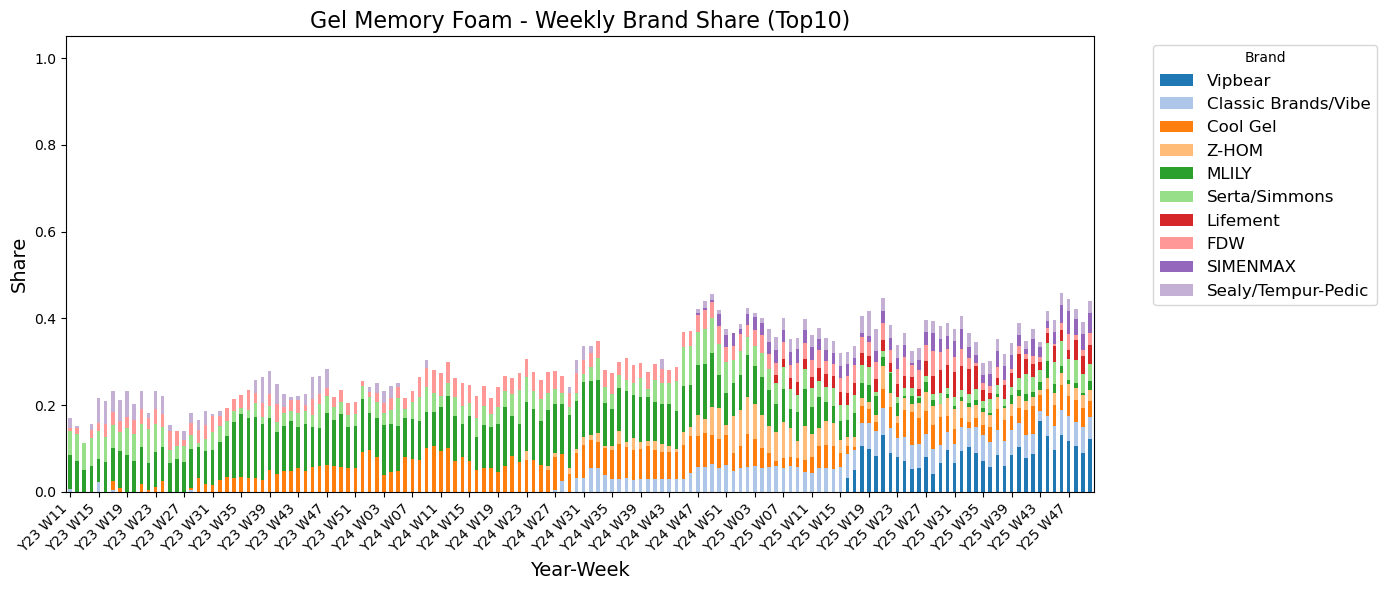

<Figure size 1400x600 with 0 Axes>

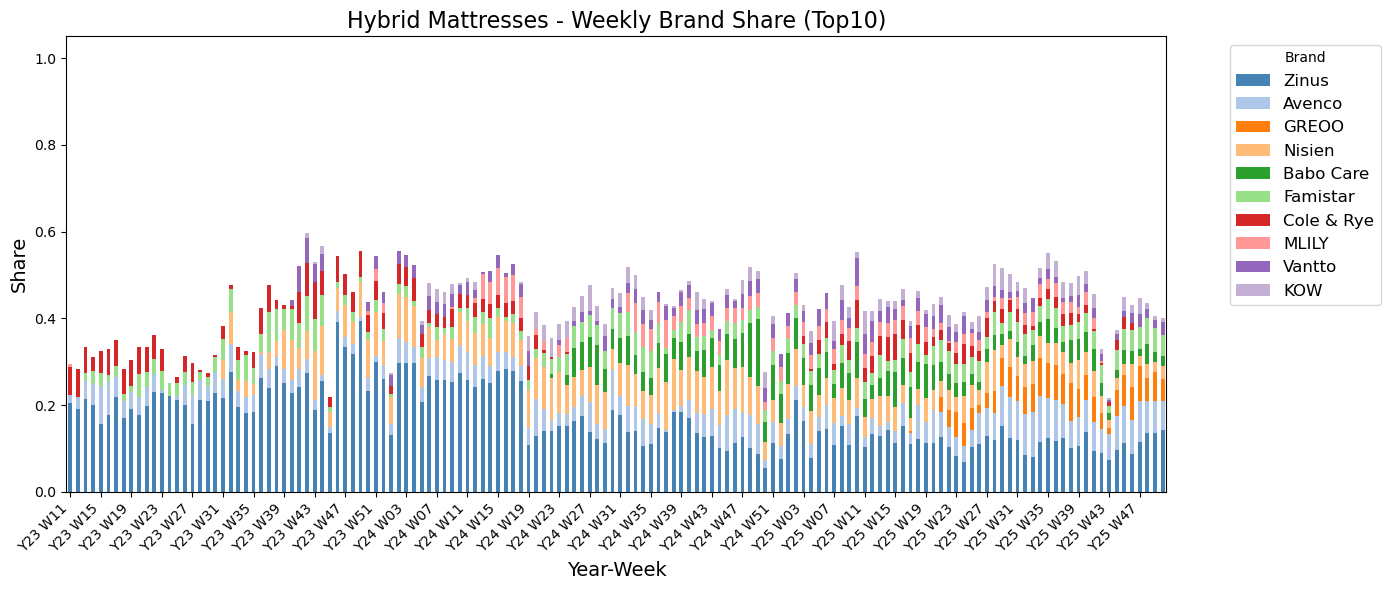

<Figure size 1400x600 with 0 Axes>

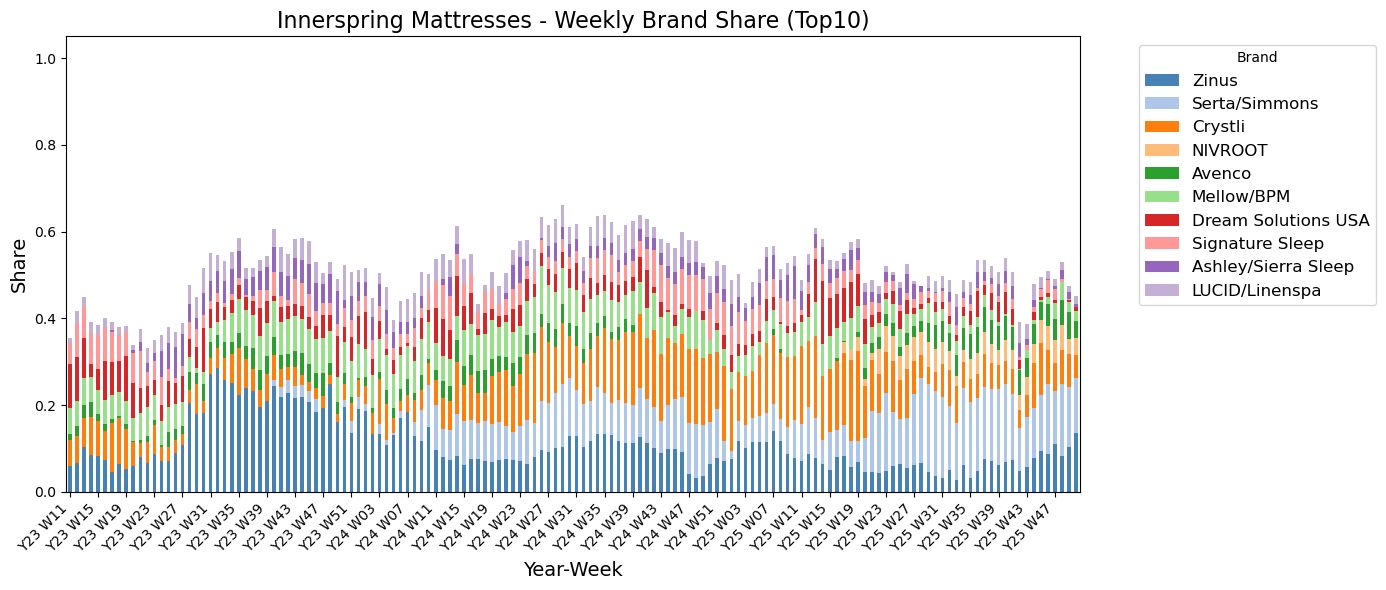

<Figure size 1400x600 with 0 Axes>

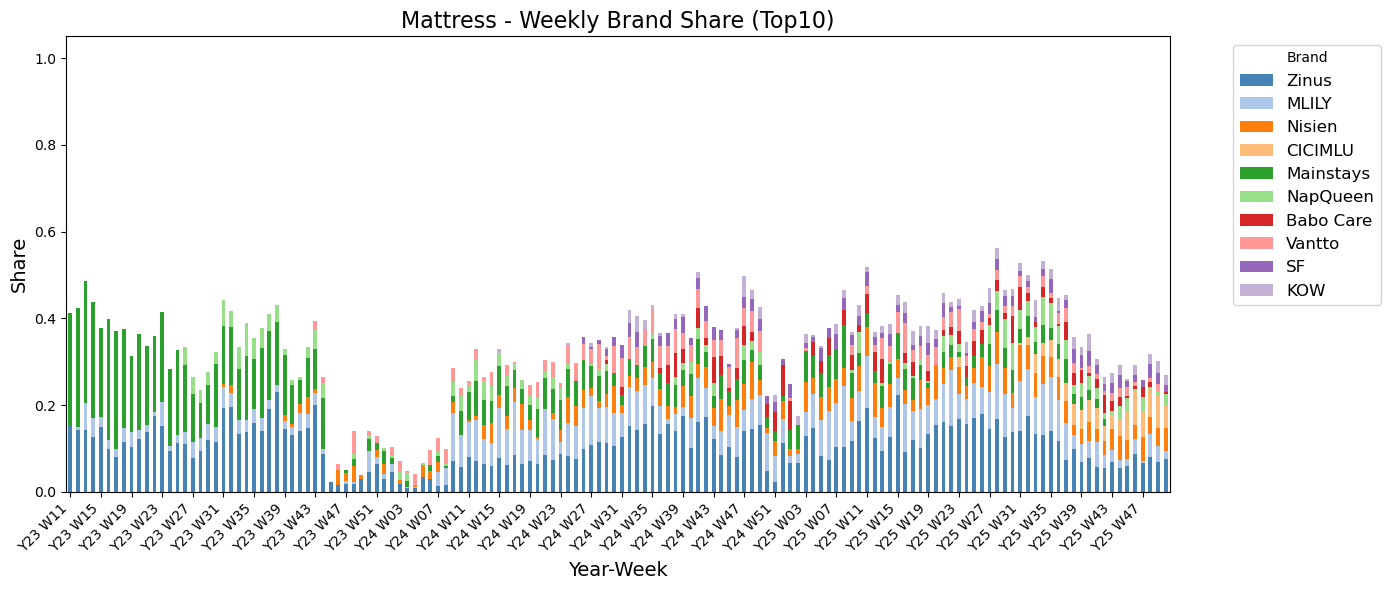

<Figure size 1400x600 with 0 Axes>

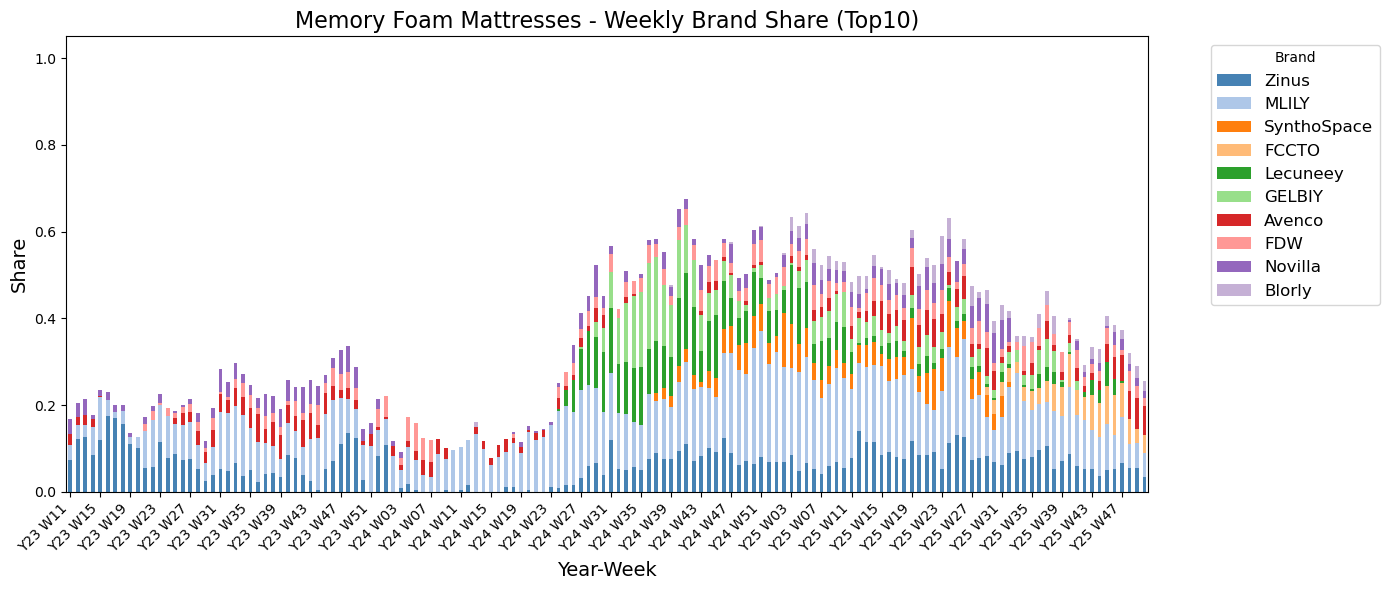

In [48]:
df2 = df1[df1['cate_type']=='matt'].copy()
plot_weekly_brand_share_for_all_categories2(df2)

#### + 2025년 점유율

In [23]:
def plot_2025_category_brand_barh_grid(
    df,
    yr_week_col='yr_week',
    category_col='category',
    brand_col='brand',
    is_zinus_col='is_zinus_prod',
    unify_zinus=True,
    top_n=10,
    year_prefix='Y25',
    ncols=2   # ⭐ 2열 고정
):
    df_use = df.copy()

    # --- 0. 2025년 데이터만 필터링 ---
    df_use = df_use[df_use[yr_week_col].astype(str).str.startswith(year_prefix)]
    if df_use.empty:
        print(f"[INFO] {year_prefix} 로 시작하는 {yr_week_col} 데이터가 없습니다.")
        return

    # Zinus 통합
    if unify_zinus and is_zinus_col in df_use.columns:
        df_use.loc[df_use[is_zinus_col] == 'Y', brand_col] = 'Zinus'

    categories = sorted(df_use[category_col].dropna().unique().tolist())
    n_cat = len(categories)

    # ---------------------------------------------------------
    # ⭐ 카테고리 수에 따라 필요한 행(row) 수 계산
    # ---------------------------------------------------------
    nrows = math.ceil(n_cat / ncols)   # ncols=2 고정

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(5 * ncols, 4 * nrows))
    if isinstance(axes, plt.Axes):
        axes = [axes]
    else:
        axes = axes.flatten()

    default_colors = plt.cm.tab20.colors

    for i, cat in enumerate(categories):
        ax = axes[i]

        df_cat = df_use[df_use[category_col] == cat].copy()
        if df_cat.empty:
            ax.axis('off')
            continue

        # --- 브랜드 count ---
        brand_counts = (
            df_cat.groupby(brand_col).size()
                  .rename('brand_count')
                  .reset_index()
        )
        total_count = brand_counts['brand_count'].sum()

        # Top N
        top_brands = (
            brand_counts.sort_values('brand_count', ascending=False)
                        .head(top_n)[brand_col]
                        .tolist()
        )

        brand_counts['brand_adj'] = brand_counts[brand_col].where(
            brand_counts[brand_col].isin(top_brands), 'Others'
        )

        brand_summary = (
            brand_counts.groupby('brand_adj')['brand_count']
                        .sum()
                        .reset_index()
        )
        brand_summary['share'] = brand_summary['brand_count'] / total_count

        # ⭐ Others 항상 맨 아래
        brand_summary['is_others'] = (brand_summary['brand_adj'] == 'Others').astype(int)
        brand_summary = brand_summary.sort_values(
            ['is_others', 'share'],
            ascending=[False, True]
        ).drop(columns=['is_others'])

        labels = brand_summary['brand_adj'].tolist()
        shares = brand_summary['share'].tolist()

        # 색상
        color_map = {}
        for j, b in enumerate(labels):
            if b == 'Zinus':
                color_map[b] = 'steelblue'
            elif b == 'Others':
                color_map[b] = 'lightgrey'
            else:
                color_map[b] = default_colors[j % len(default_colors)]
        colors = [color_map[b] for b in labels]

        # plot
        ax.barh(labels, shares, color=colors)
        ax.set_xlim(0, 1)

        # percent labels
        for y_pos, val in enumerate(shares):
            ax.text(val + 0.01, y_pos,
                    f"{val*100:.1f}%",
                    va='center')

        ax.set_title(f"{cat}")
        ax.set_xlabel('Share')
        ax.set_ylabel('Brand')

    # 남는 AX는 숨기기
    for k in range(i + 1, len(axes)):
        axes[k].axis('off')

    plt.suptitle(
        f"{year_prefix} Brand Share by Category (Top {top_n} + Others)",
        fontsize=16,
        y=0.98
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # 결과 그래프 저장하기
    #filename = f"y25_bsr_top10.png"
    #save_path = os.path.join(save_folder, filename)
    #plt.savefig(filename, dpi=350, bbox_inches='tight')

    plt.show()

# === 사용 예시 ===
# yr_week가 'Y25 W01' 형식이라고 가정
# df : Walmart / Wayfair 통합 BSR 데이터프레임
#plot_2025_category_brand_barh_grid(df)

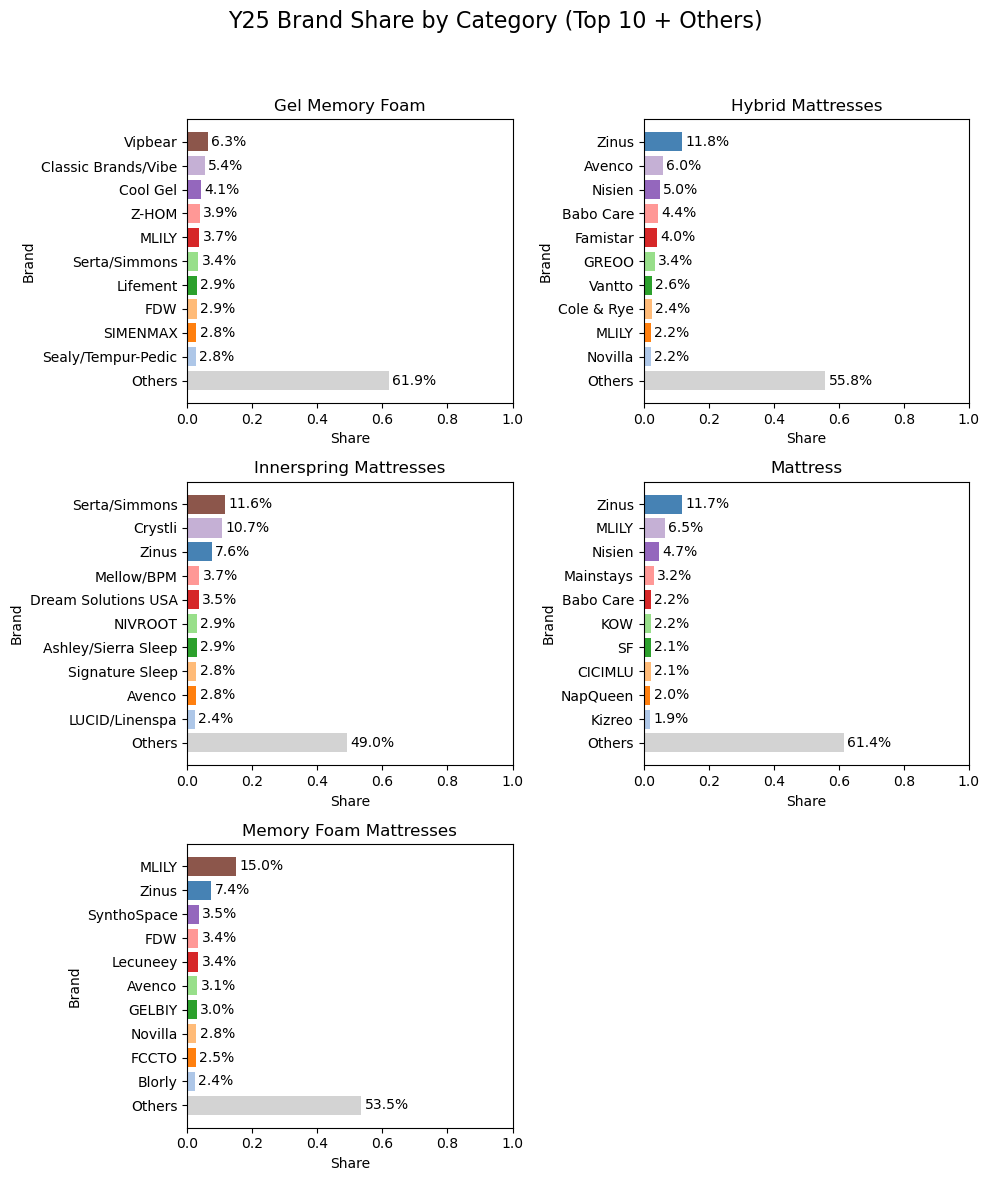

In [25]:
df2 = df1[df1['cate_type']=='matt'].copy()
plot_2025_category_brand_barh_grid(df2)

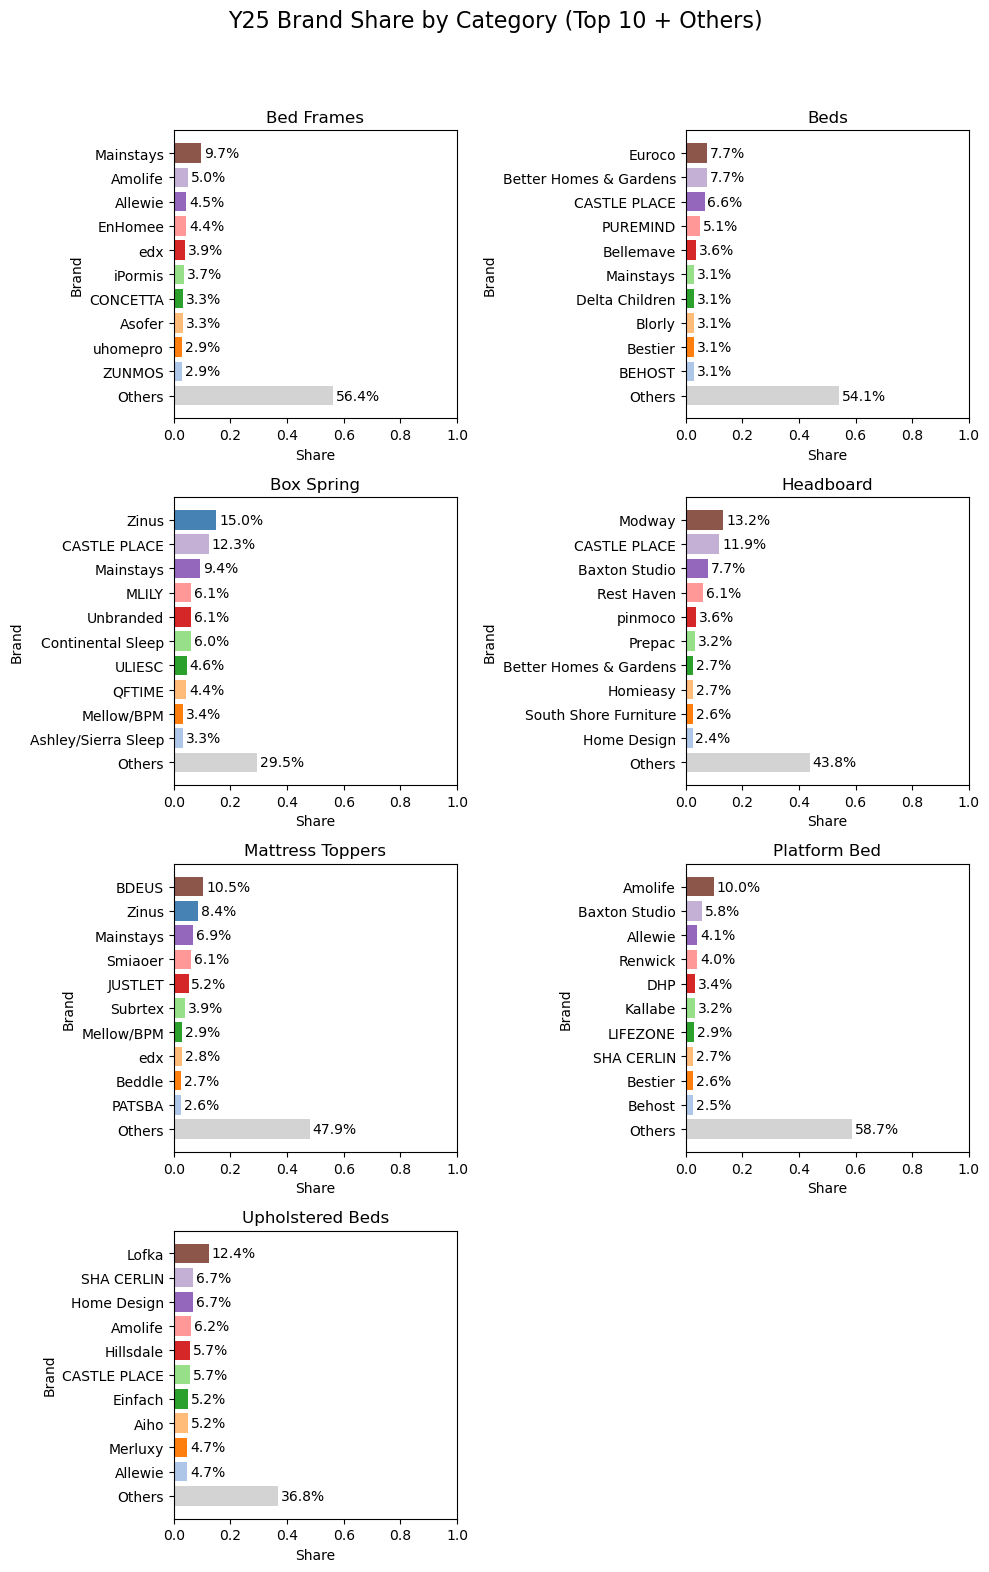

In [97]:
df2 = df1[df1['cate_type']=='non-matt'].copy()
plot_2025_category_brand_barh_grid(df2)

In [75]:
def plot_2025_category_brand_barh_each(
    df,
    yr_week_col='yr_week',
    category_col='category',
    brand_col='brand',
    is_zinus_col='is_zinus_prod',
    unify_zinus=True,
    top_n=10,
    year_prefix='Y25',
    figsize=(7, 5)   # 카테고리별 개별 그래프 크기
):
    df_use = df.copy()

    # --- 0. 2025년 데이터만 필터링 ---
    df_use = df_use[df_use[yr_week_col].astype(str).str.startswith(year_prefix)]
    if df_use.empty:
        print(f"[INFO] {year_prefix} 로 시작하는 {yr_week_col} 데이터가 없습니다.")
        return

    # Zinus 통합
    if unify_zinus and is_zinus_col in df_use.columns:
        df_use.loc[df_use[is_zinus_col] == 'Y', brand_col] = 'Zinus'

    categories = sorted(df_use[category_col].dropna().unique().tolist())
    default_colors = plt.cm.tab20.colors

    for cat in categories:
        df_cat = df_use[df_use[category_col] == cat].copy()
        if df_cat.empty:
            print(f"[SKIP] category='{cat}' : 데이터 없음")
            continue

        # --- 브랜드 count ---
        brand_counts = (
            df_cat.groupby(brand_col).size()
                  .rename('brand_count')
                  .reset_index()
        )
        total_count = brand_counts['brand_count'].sum()

        # Top N
        top_brands = (
            brand_counts.sort_values('brand_count', ascending=False)
                        .head(top_n)[brand_col]
                        .tolist()
        )

        brand_counts['brand_adj'] = brand_counts[brand_col].where(
            brand_counts[brand_col].isin(top_brands), 'Others'
        )

        brand_summary = (
            brand_counts.groupby('brand_adj')['brand_count']
                        .sum()
                        .reset_index()
        )
        brand_summary['share'] = brand_summary['brand_count'] / total_count

            # === Others 항상 맨 아래로 정렬 ===
        others_row = brand_summary[brand_summary['brand_adj'] == 'Others']
        main_rows = brand_summary[brand_summary['brand_adj'] != 'Others']
        
        # main 브랜드는 share 기준 오름차순 (작은 게 위, 큰 게 아래)
        main_rows = main_rows.sort_values('share', ascending=True)
        
        # Others를 마지막에 붙이기 → barh에서 맨 아래
        brand_summary = (
            #pd.concat([main_rows, others_row], ignore_index=True)
            pd.concat([others_row, main_rows], ignore_index=True)
            if not others_row.empty else main_rows
        )

        labels = brand_summary['brand_adj'].tolist()
        shares = brand_summary['share'].tolist()

        # 색상
        color_map = {}
        for j, b in enumerate(labels):
            if b == 'Zinus':
                color_map[b] = 'steelblue'
            elif b == 'Others':
                color_map[b] = 'lightgrey'
            else:
                color_map[b] = default_colors[j % len(default_colors)]
        colors = [color_map[b] for b in labels]

        # ✅ 카테고리별 독립 Figure
        fig, ax = plt.subplots(1, 1, figsize=figsize)

        ax.barh(labels, shares, color=colors)
        ax.set_xlim(0, 1)

       # ax.invert_yaxis()  # ✅ 여기
        
        # percent labels
        for y_pos, val in enumerate(shares):
            ax.text(val + 0.01, y_pos, f"{val*100:.1f}%", va='center')

        ax.set_title(f"{year_prefix} - {cat} (Top {top_n} + Others)")
        ax.set_xlabel('Share')
        ax.set_ylabel('Brand')

        plt.tight_layout()
        plt.show()

In [77]:
df2 = df1[df1['cate_type']=='matt'].copy()
plot_2025_category_brand_barh_each(df2, top_n=10, year_prefix='Y25')

NameError: name 'df1' is not defined

## 3. Price & Review 

In [11]:
df3 = df.copy()
df3['bsr_date'] = pd.to_datetime(df3['bsr_date'], errors='coerce')
df3['year'] = df3['bsr_date'].dt.year

In [13]:
print(df3)

                category is_zinus_prod product_item_id  \
0                   Beds             N     15466559093   
1                   Beds             N      5595252084   
2       Upholstered Beds             N     13389818989   
3       Upholstered Beds             N     13260421535   
4       Upholstered Beds             N      5282753802   
...                  ...           ...             ...   
333710        Bed Frames             N       386779481   
333711        Bed Frames             N       517565914   
333712        Bed Frames             N      1957016855   
333713        Bed Frames             N       301776819   
333714        Bed Frames             N       815294738   

                                              product_url  \
0       https://www.walmart.com/ip/Feonase-Full-Bed-Fr...   
1       https://www.walmart.com/ip/OXYLIFE-Murphy-Bed-...   
2       https://www.walmart.com/ip/Hiphuta-Queen-LED-B...   
3       https://www.walmart.com/ip/Hiphuta-Queen-Size-...  

In [93]:
top_n = 11
base_year = 2025  # 2025년 기준 Top10, 없으면 전체기간
category_col = 'category'
brand_col = 'brand'
year_col = 'year'
is_zinus_col = 'is_zinus_prod'

cate_list = df3[category_col].dropna().unique()

top10_by_category = {}   # {category: [brand1, brand2, ...]}
rows = []                # 요약표용

for cat in sorted(cate_list):
    df_cat = df3[df3[category_col] == cat].copy()
    if df_cat.empty:
        continue

    # Zinus 통합 (옵션)
    if is_zinus_col in df_cat.columns:
        df_cat.loc[df_cat[is_zinus_col] == 'Y', brand_col] = 'Zinus'

    # year/brand별 count
    yearly_brand_counts = (
        df_cat.groupby([year_col, brand_col])
              .size()
              .reset_index(name='brand_count')
    )

    # 2025년 기준 Top10 (없으면 전체기간 기준)
    df_base = yearly_brand_counts[yearly_brand_counts[year_col] == base_year]
    if df_base.empty:
        top_brands = (
            yearly_brand_counts.groupby(brand_col)['brand_count']
                               .sum()
                               .sort_values(ascending=False)
                               .head(top_n)
                               .index
                               .tolist()
        )
        bs = f"ALL(->{base_year} 없음)"
    else:
        top_brands = (
            df_base.sort_values('brand_count', ascending=False)
                   .head(top_n)[brand_col]
                   .tolist()
        )
        bs = str(base_year)

    print(top_brands)
    
    top10_by_category[cat] = top_brands

    

#print(top10_by_category)

['Mainstays', 'Amolife', 'Allewie', 'EnHomee', 'edx', 'iPormis', 'CONCETTA', 'Asofer', 'uhomepro', 'ZUNMOS', 'FSCHOS']
['Better Homes & Gardens', 'Euroco', 'CASTLE PLACE', 'PUREMIND', 'Bellemave', 'Delta Children', 'Mainstays', 'BEHOST', 'Bestier', 'Blorly', 'Yaheetech']
['Zinus', 'CASTLE PLACE', 'Mainstays', 'Unbranded', 'MLILY', 'Continental Sleep', 'ULIESC', 'QFTIME', 'Mellow/BPM', 'Ashley/Sierra Sleep', 'ZIYOO']
['Vipbear', 'Classic Brands/Vibe', 'Cool Gel', 'Z-HOM', 'MLILY', 'Serta/Simmons', 'Lifement', 'SIMENMAX', 'LUCID/Linenspa', 'Sealy/Tempur-Pedic', 'FDW']
['Modway', 'CASTLE PLACE', 'Baxton Studio', 'Rest Haven', 'pinmoco', 'Prepac', 'Better Homes & Gardens', 'Homieasy', 'South Shore Furniture', 'Home Design', 'Weture']
['Zinus', 'Avenco', 'Nisien', 'Babo Care', 'Famistar', 'GREOO', 'Vantto', 'Cole & Rye', 'KOW', 'MLILY', 'Novilla']
['Serta/Simmons', 'Crystli', 'Zinus', 'Mellow/BPM', 'Dream Solutions USA', 'NIVROOT', 'Ashley/Sierra Sleep', 'Signature Sleep', 'Avenco', 'serspe

In [95]:
# Category별로 Top Brand의 data 추출하기
df3y = df3[df3['year']==2025].copy()

for cat, top_brands in top10_by_category.items():
#    if cat != 'Bed Frames': 
#        continue
    
    # ① 해당 category만 필터링
    df_cat = df3y[df3y[category_col] == cat].copy()
    if df_cat.empty:
        continue

    # ② 해당 category의 Top10 브랜드만 필터링
    df_cat_top10 = df_cat[df_cat[brand_col].isin(top_brands)].copy()

    # 동일 시간 중복이면 "마지막"이 남도록 정렬 후 tail(1)
    df_cat_top10 = df_cat_top10.sort_values(['product_item_id', 'bsr_date'])

    df_latest = (
        df_cat_top10
        .groupby(['category', 'product_item_id'], as_index=False)
        .tail(1)
    )
    
    # 1) (category, brand)별 seller_type(1P/2P/3P) ASIN 개수 → wide 형태
    seller_cnt = (
        df_latest
        .pivot_table(
            index=['category', 'brand'],
            columns='seller_type',
            values='product_item_id',
            aggfunc=pd.Series.nunique,
            fill_value=0
        )
        .reset_index()
    )
    #print(seller_cnt)

        # 2) 평균 지표 계산
    metrics = (
        df_latest
        .groupby(['category', 'brand'], as_index=False)
        .agg(
            avg_rank=('rank', 'mean'),
            avg_rating=('rating', 'mean'),
            avg_retail_price=('retail_price', 'mean'),
            product_item_cnt=('product_item_id', 'nunique')   # 전체 ASIN 수(참고용)
        )
    )
    #print(metrics)   

    # 3) 결합
    result = (
        metrics
        .merge(seller_cnt, on=[category_col, brand_col], how='left')
    )
    print(result) 

#    print(latest)
    print(f"\n==== Category: {cat} | unique_asin={latest['product_item_id'].nunique()} | rows={len(latest)} ====\n\n")
#    print(f"\n==== Category: {cat} | rows={len(df_cat_top10)} ====")

      category      brand   avg_rank  avg_rating  avg_retail_price  \
0   Bed Frames    Allewie  22.769231    4.400000        195.768462   
1   Bed Frames    Amolife  29.692308    4.530769        121.252308   
2   Bed Frames     Asofer  26.214286    4.564286        105.272143   
3   Bed Frames   CONCETTA       19.5    4.410000        114.011000   
4   Bed Frames    EnHomee  23.133333    4.173333        183.756000   
5   Bed Frames     FSCHOS       22.0    4.433333         57.340000   
6   Bed Frames  Mainstays  19.909091    4.609091         89.561818   
7   Bed Frames     ZUNMOS       23.0    4.371429         60.947143   
8   Bed Frames        edx  23.538462    4.376923         87.151538   
9   Bed Frames    iPormis  26.913043    4.495652        129.121739   
10  Bed Frames   uhomepro  29.166667    4.350000        106.123333   

    product_item_cnt  1P  3P  
0                 13   0  13  
1                 13   0  13  
2                 14   0  14  
3                 10   0  10  
4   

## 4. BSR + 매출 그래프

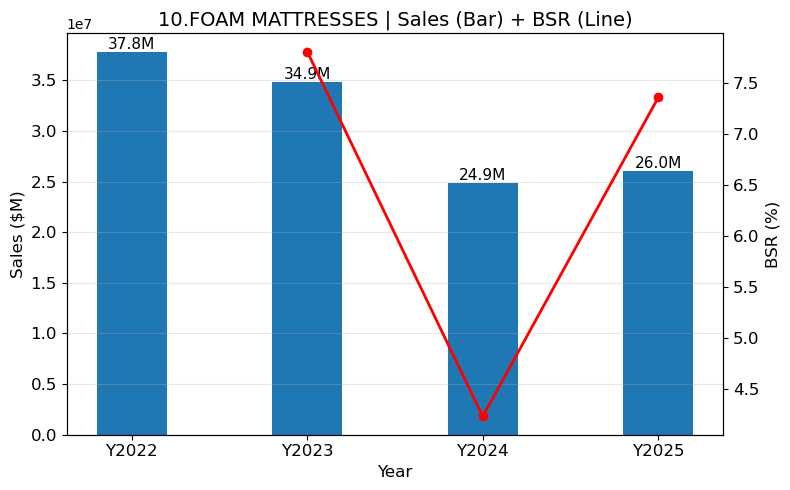

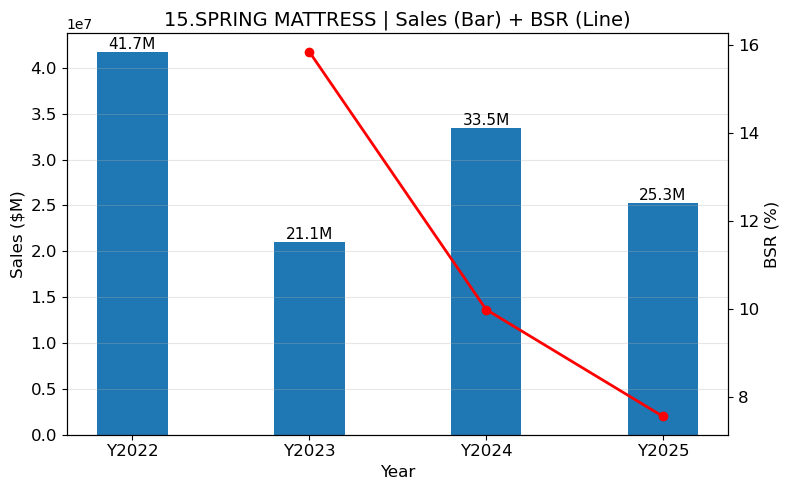

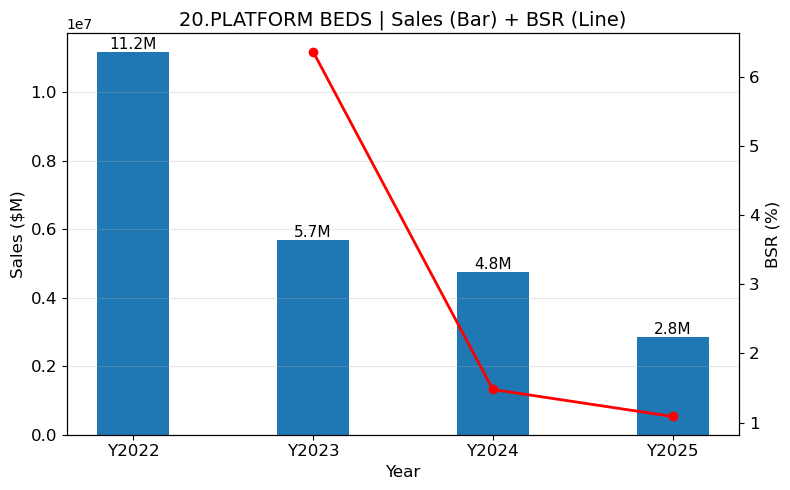

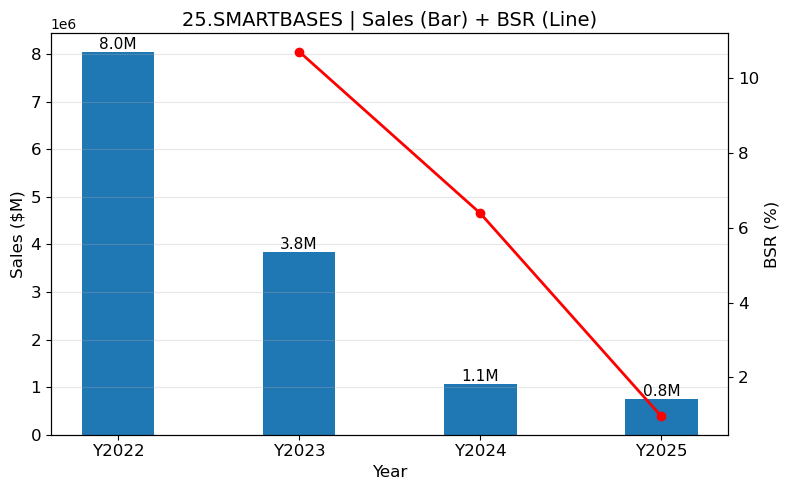

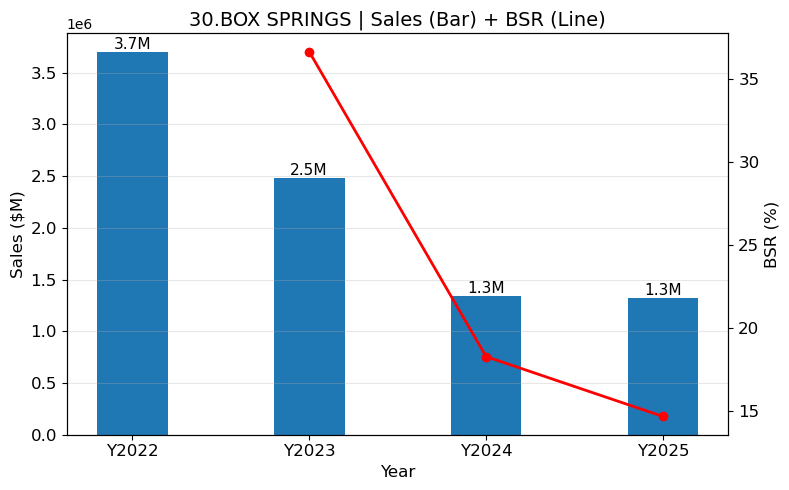

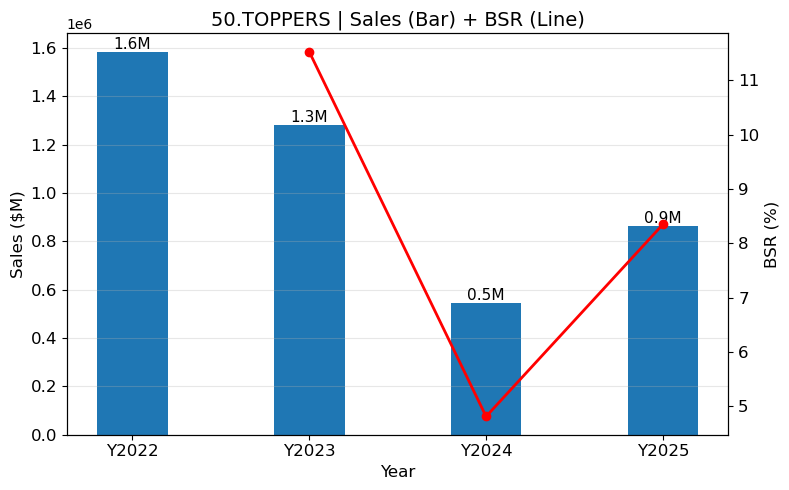

In [47]:

# -------------------------
# Data
# -------------------------
data = [
    ("10.FOAM MATTRESSES",  "매출",   37754789, 34884303, 24906995, 26042109),
    ("10.FOAM MATTRESSES",  "BSR(%)", None,     7.81,     4.23,     7.36),

    ("15.SPRING MATTRESS",  "매출",   41690347, 21050664, 33486425, 25275822),
    ("15.SPRING MATTRESS",  "BSR(%)", None,     15.84,    9.98,     7.55),

    ("20.PLATFORM BEDS",    "매출",   11154343, 5674279,  4750346,  2841234),
    ("20.PLATFORM BEDS",    "BSR(%)", None,     6.36,     1.48,     1.09),

    ("25.SMARTBASES",       "매출",   8035332,  3835915,  1064097,  753083),
    ("25.SMARTBASES",       "BSR(%)", None,     10.72,    6.39,     0.95),

    ("30.BOX SPRINGS",      "매출",   3695727,  2482997,  1339269,  1323804),
    ("30.BOX SPRINGS",      "BSR(%)", None,     36.67,    18.29,    14.68),

    ("50.TOPPERS",          "매출",   1582120,  1283057,  544202,   862640),
    ("50.TOPPERS",          "BSR(%)", None,     11.53,    4.81,     8.35),
]

years = ["Y2022", "Y2023", "Y2024", "Y2025"]
df = pd.DataFrame(data, columns=["category", "metric"] + years)

# -------------------------
# Font size config
# -------------------------
TITLE_FS = 14
AXIS_LABEL_FS = 12
TICK_FS = 12
BAR_LABEL_FS = 11

# -------------------------
# Plot (bar width reduced by half)
# -------------------------
for cat, g in df.groupby("category"):
    sales_row = g[g["metric"] == "매출"].iloc[0]
    bsr_row   = g[g["metric"] == "BSR(%)"].iloc[0]

    sales = [sales_row[y] for y in years]
    bsr   = [bsr_row[y] for y in years]

    fig, ax1 = plt.subplots(figsize=(8, 5))

    # Sales bar (thinner bars)
    bars = ax1.bar(
        years,
        sales,
        width=0.4   # ✅ 기본(0.8) 대비 절반 두께
    )
    ax1.set_ylabel("Sales ($M)", fontsize=AXIS_LABEL_FS)
    ax1.set_xlabel("Year", fontsize=AXIS_LABEL_FS)
    ax1.tick_params(axis="both", labelsize=TICK_FS)

    # Bar labels (Million)
    for bar, val in zip(bars, sales):
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{val/1e6:.1f}M",
            ha="center",
            va="bottom",
            fontsize=BAR_LABEL_FS
        )

    # BSR line (black)
    ax2 = ax1.twinx()
    ax2.plot(
        years,
        bsr,
        color="red",
        marker="o",
        linewidth=2
    )
    ax2.set_ylabel("BSR (%)", fontsize=AXIS_LABEL_FS)
    ax2.tick_params(axis="y", labelsize=TICK_FS)

    # Title
    ax1.set_title(f"{cat} | Sales (Bar) + BSR (Line)", fontsize=TITLE_FS)

    # Grid
    ax1.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()